# 🐄 Livestock Behavior Classification — Exploratory Data Analysis

**Dataset** : Japanese cattle accelerometer dataset (6 cows, 25 Hz)  
**Sensor**  : 3-axis accelerometer (AccX, AccY, AccZ) in *g*  
**Goal**    : Characterize the dataset, validate the pre-processing pipeline,  
and produce publication-ready figures for the Master Research thesis.

---

### Table of Contents
1. [Setup & Imports](#1)
2. [Data Loading & Overview](#2)
3. [Label Distribution](#3)
4. [Per-animal Analysis](#4)
5. [Raw Signal Visualization](#5)
6. [Behavior-specific Signal Patterns](#6)
7. [Downsampling 25 Hz → 10 Hz](#7)
8. [Feature Extraction](#8)
9. [Feature Distributions per Behavior](#9)
10. [Correlation Analysis](#10)
11. [Inter-animal Variability (LOAO perspective)](#11)
12. [Class Imbalance](#12)
13. [ML Training & LOAO Cross-validation](#13)
14. [Results — Confusion Matrix](#14)
15. [Results — Feature Importance](#15)
16. [Results — PCA Feature Space](#16)
17. [Synthesis & Conclusions](#17)


## 1. Setup & Imports <a id='1'></a>

In [10]:
import warnings
warnings.filterwarnings("ignore")

import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from scipy import signal as sp_signal
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA

# ── Aesthetic configuration ──────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi"      : 150,
    "savefig.dpi"     : 150,
    "axes.spines.top" : False,
    "axes.spines.right": False,
})

BEHAVIOR_PALETTE = {
    "lying"   : "#4A90D9",
    "standing": "#7DB87A",
    "walking" : "#F5A623",
    "running" : "#D0021B",
}

# ── Paths ────────────────────────────────────────────────────────────────────
DATA_DIR  = Path("../ml/data")          # adjust if running from a different CWD
MODEL_DIR = Path("../ml/models")

print("Paths configured.")
print(f"  DATA_DIR  : {DATA_DIR.resolve()}")
print(f"  MODEL_DIR : {MODEL_DIR.resolve()}")


Paths configured.
  DATA_DIR  : C:\Users\oumba\Documents\livestock-monitoring\backend\ml\data
  MODEL_DIR : C:\Users\oumba\Documents\livestock-monitoring\backend\ml\models


## 2. Data Loading & Overview <a id='2'></a>

We load the 6 CSV files and create a unified dataframe tagged with the animal ID.  
Each file represents one cow monitored over a recording session.


In [11]:
# ── Constants (must match train.py) ─────────────────────────────────────────
ORIGINAL_FREQ        = 25
TARGET_FREQ          = 10
WINDOW_SECONDS       = 5
WINDOW_SAMPLES       = TARGET_FREQ * WINDOW_SECONDS    # 50
LABEL_PURITY         = 0.80
EXCLUDED_LABELS      = {"BLN", "ETC", ""}
SIMPLIFIED_STATES    = ["lying", "standing", "walking", "running"]
FEATURE_COLUMNS      = [
    "accel_x_mean", "accel_x_std", "accel_x_min", "accel_x_max",
    "accel_y_mean", "accel_y_std", "accel_y_min", "accel_y_max",
    "accel_z_mean", "accel_z_std", "accel_z_min", "accel_z_max",
]
# BEHAVIOR_MAP = {
#     "LIE": "lying",  "LYI": "lying",  "LSL": "lying",  "LFA": "lying",  "LRU": "lying",
#     "STA": "standing","STD": "standing","SRU": "standing","GRA": "standing","GRZ": "standing",
#     "WAL": "walking", "WLK": "walking",
#     "RUN": "running", "TRO": "running",
# }

BEHAVIOR_MAP = {
    # --- STANDING CATEGORY ---
    "RES": "standing",  # Resting in standing position
    "RUS": "standing",  # Ruminating in standing position
    "GRZ": "standing",  # Grazing (head down, but stationary/slow)
    "FES": "standing",  # Feeding in stancheon
    "SLT": "standing",  # Salt licking
    "DRN": "standing",  # Drinking
    "LCK": "standing",  # Licking
    "URI": "standing",  # Urinating
    "BMN": "standing",  # Being mounted

    # --- LYING CATEGORY ---
    "REL": "lying",     # Resting in lying position

    # --- WALKING CATEGORY ---
    "MOV": "walking",   # Moving

    # --- RUNNING CATEGORY ---
    "ATT": "running",   # Attacking (high intensity)
    "ESC": "running",   # Escaping (high intensity)
}

In [12]:
# import each dataset from cow1 to cow6 and display it with the unique behaviors for each cow separately
for cow_id in range(1, 7):
    df = pd.read_csv(DATA_DIR / f"cow{cow_id}.csv")
    print(f"cow{cow_id}:\n{df['Label'].unique()}\n")


cow1:
<StringArray>
[nan, 'ETC', 'RES', 'URI', 'MOV', 'ATT', 'FES', 'GRZ', 'RUS', 'DRN', 'SLT']
Length: 11, dtype: str

cow2:
<StringArray>
[nan, 'ETC', 'MOV', 'REL', 'RES', 'RUS', 'GRZ', 'BMN', 'ATT']
Length: 9, dtype: str

cow3:
<StringArray>
[nan, 'ETC', 'RES', 'MOV', 'URI', 'LCK', 'DRN', 'RUS', 'SLT']
Length: 9, dtype: str

cow4:
<StringArray>
[nan, 'ETC', 'MOV', 'RES', 'ATT', 'LCK', 'REL', 'ESC', 'GRZ', 'RUS']
Length: 10, dtype: str

cow5:
<StringArray>
[nan, 'ETC', 'MOV', 'RES', 'FES', 'GRZ']
Length: 6, dtype: str

cow6:
<StringArray>
[nan, 'ETC', 'RES', 'MOV', 'GRZ', 'ATT', 'LCK']
Length: 7, dtype: str



In [13]:
# ── Load ─────────────────────────────────────────────────────────────────────
dfs = []
for path in sorted(DATA_DIR.glob("cow*.csv")):
    df = pd.read_csv(path, dtype={"Label": str})
    df["animal_id"] = path.stem
    dfs.append(df)

raw = pd.concat(dfs, ignore_index=True)
raw["Label"] = raw["Label"].fillna("").str.strip().str.upper()
raw["datetime"] = pd.to_datetime(raw["TimeStamp_UNIX"], unit="ms")

print(f"Rows loaded      : {len(raw):,}")
print(f"Animals          : {sorted(raw['animal_id'].unique())}")
print(f"Columns          : {list(raw.columns)}")
print(f"\nSample range per animal:")
raw.groupby("animal_id")["datetime"].agg(["min","max","count"]).rename(
    columns={"min":"start","max":"end","count":"n_rows"}
).assign(duration_min=lambda d:(d["end"]-d["start"]).dt.total_seconds()/60).round(1)

Rows loaded      : 1,391,224
Animals          : ['cow1', 'cow2', 'cow3', 'cow4', 'cow5', 'cow6']
Columns          : ['TimeStamp_UNIX', 'TimeStamp_JST', 'AccX', 'AccY', 'AccZ', 'Label', 'animal_id', 'datetime']

Sample range per animal:


,start,end,n_rows,duration_min
animal_id,,,,
cow1,2020-06-12 02:22:57.026,2020-06-12 08:21:47.976,311876,358.8
cow2,2020-06-12 02:51:02.622,2020-06-12 08:21:37.941,269772,330.6
cow3,2020-06-12 02:50:23.678,2020-06-12 08:21:09.983,269903,330.8
cow4,2020-06-12 02:50:52.714,2020-06-12 07:51:33.980,224912,300.7
cow5,2020-06-12 02:49:55.711,2020-06-12 04:20:04.998,134904,90.2
cow6,2020-06-12 03:12:13.469,2020-06-12 08:12:54.965,179857,300.7


In [14]:
raw.sample(5)

,TimeStamp_UNIX,TimeStamp_JST,AccX,AccY,AccZ,Label,animal_id,datetime
137625,1591934098056,12:54:58.056000,0.008,1.001,0.290,RES,cow1,2020-06-12 03:54:58.056
1327272,1591947010411,16:30:10.411000,0.006,0.251,0.946,ETC,cow6,2020-06-12 07:30:10.411
938766,1591933746785,12:49:06.785000,0.157,1.001,0.299,MOV,cow4,2020-06-12 03:49:06.785
807041,1591948288774,16:51:28.774000,-0.070,1.025,0.177,,cow3,2020-06-12 07:51:28.774
1365743,1591948555715,16:55:55.715000,-0.269,0.780,0.586,RES,cow6,2020-06-12 07:55:55.715


In [15]:
raw.describe()

,TimeStamp_UNIX,AccX,AccY,AccZ,datetime
count,1.391224e+06,1.391224e+06,1.391224e+06,1.391224e+06,1391224
mean,1.591939e+12,-6.336187e-02,7.306002e-01,4.346481e-01,2020-06-12 05:14:59.530000
min,1.591929e+12,-2.823000e+00,-2.340000e+00,-2.336000e+00,2020-06-12 02:22:57.026000
25%,1.591932e+12,-1.700000e-01,5.400000e-01,1.620000e-01,2020-06-12 03:28:18.697000
50%,1.591935e+12,-5.100000e-02,8.150000e-01,4.840000e-01,2020-06-12 04:07:03.152000
75%,1.591947e+12,3.500000e-02,1.015000e+00,7.550000e-01,2020-06-12 07:27:21.461000
max,1.591950e+12,3.210000e+00,3.960000e+00,3.924000e+00,2020-06-12 08:21:47.976000
std,7.335299e+06,2.538430e-01,3.916876e-01,3.970552e-01,NaN


In [16]:
raw["Label"].unique()

<StringArray>
[   '', 'ETC', 'RES', 'URI', 'MOV', 'ATT', 'FES', 'GRZ', 'RUS', 'DRN', 'SLT',
 'REL', 'BMN', 'LCK', 'ESC']
Length: 15, dtype: str

<span style="color:red"> Problem</span>

### 📌 Interpretation


In [17]:
print("Missing values per column:")
print(raw.isnull().sum())
print(f"\nAccelerometer range — AccZ min: {raw.AccZ.min():.3f} g,  max: {raw.AccZ.max():.3f} g")


Missing values per column:
TimeStamp_UNIX    0
TimeStamp_JST     0
AccX              0
AccY              0
AccZ              0
Label             0
animal_id         0
datetime          0
dtype: int64

Accelerometer range — AccZ min: -2.336 g,  max: 3.924 g


In [18]:
# Check for empty strings specifically
print(f"Empty labels: {(raw['Label'] == '').sum()}")
print(f"BLN labels: {(raw['Label'] == 'BLN').sum()}")

Empty labels: 540695
BLN labels: 0


/!\ labels that were documented as BLN (Data without video) in the documentation have been imported as empty strings ('').

- Total Rows: $1,391,224$
- Minus Empty/BLN: $-540,695$
- Minus ETC: $-554,855$
- Total Usable Rows: $\approx 295,674$

In [19]:
# raw2 = raw.copy()
# raw2["Label"] = raw2["Label"].replace(["", " "], np.nan)

## 3. Label Distribution <a id='3'></a>

Understanding which behaviors are annotated, and how much data is usable vs. discarded.


In [20]:
label_counts = raw["Label"].value_counts().reset_index()
label_counts.columns = ["label", "n_rows"]
label_counts["pct"] = (label_counts["n_rows"] / len(raw) * 100).round(2)
label_counts["status"] = label_counts["label"].apply(
    lambda l: "excluded" if l in EXCLUDED_LABELS else "kept"
)
print("Label distribution in percentages:")
print(label_counts.to_string(index=False))


Label distribution in percentages:
label  n_rows   pct   status
  ETC  554855 39.88 excluded
       540695 38.86 excluded
  RES  150130 10.79     kept
  RUS   53229  3.83     kept
  MOV   50199  3.61     kept
  GRZ   17613  1.27     kept
  SLT   10858  0.78     kept
  FES    7934  0.57     kept
  DRN    2476  0.18     kept
  LCK    1302  0.09     kept
  REL     764  0.05     kept
  URI     621  0.04     kept
  ATT     366  0.03     kept
  ESC     128  0.01     kept
  BMN      54  0.00     kept


*Note: the empty line is for BLN*

**Instead of "filling in" the labels and mixing them with your good data, you can do a Discovery Analysis:**

- Keep the training/testing limited to the labeled data (the 21% kept).

- Use the model to predict the behaviors in the "BLN" section.

- Compare the results

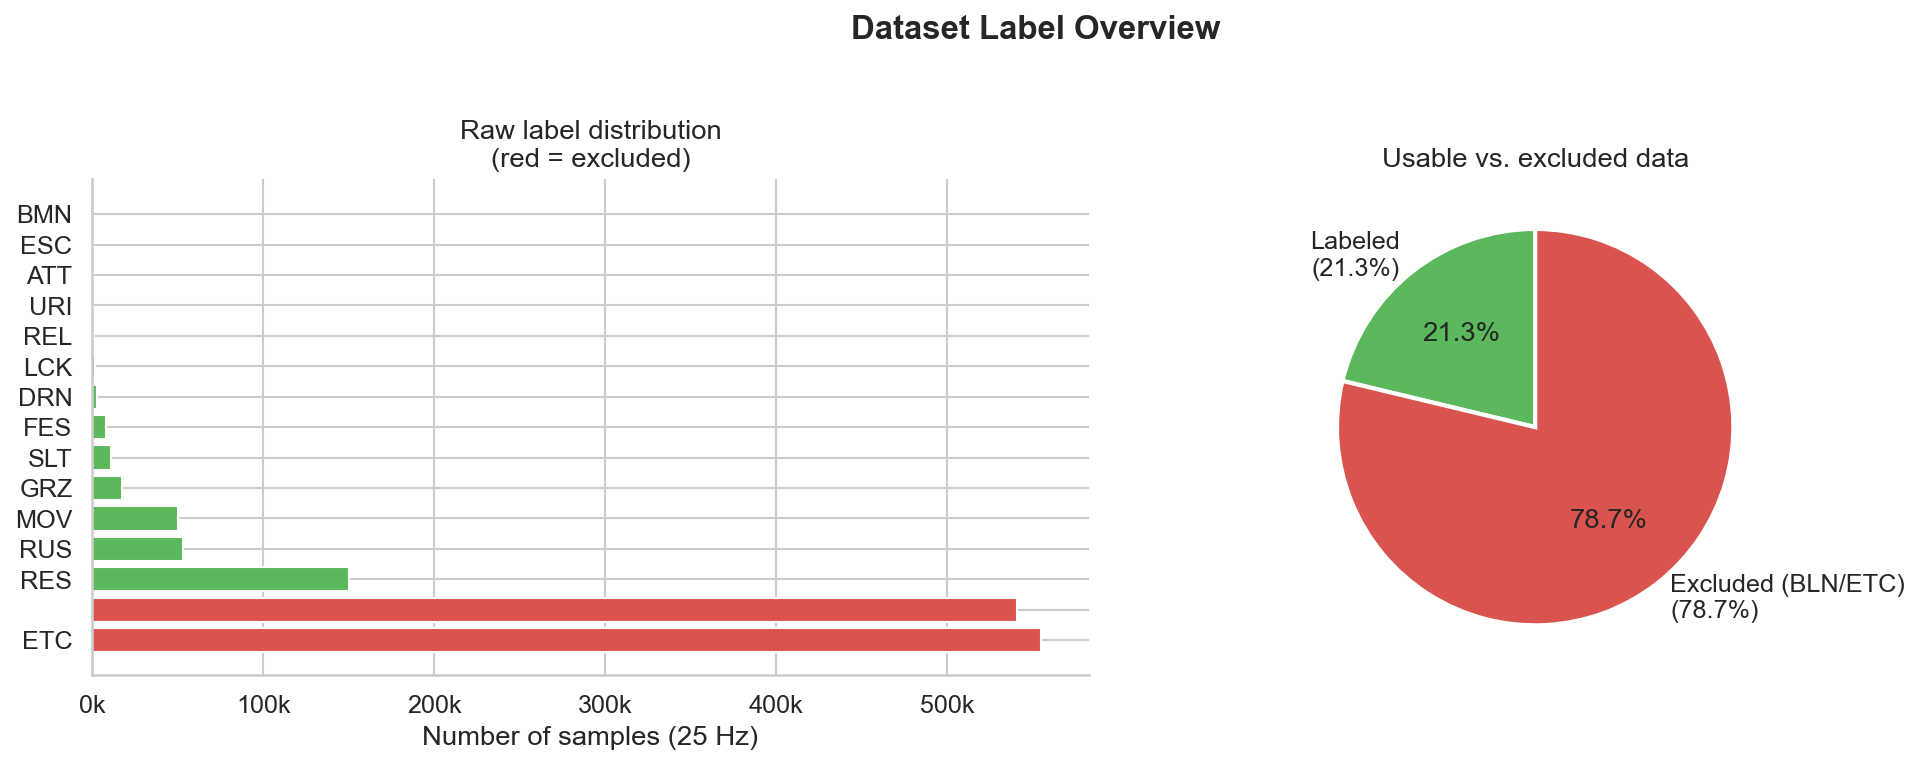

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: raw label counts ────────────────────────────────────────────────
colors = ["#D9534F" if s == "excluded" else "#5CB85C"
          for s in label_counts["status"]]
axes[0].barh(label_counts["label"], label_counts["n_rows"], color=colors)
axes[0].set_xlabel("Number of samples (25 Hz)")
axes[0].set_title("Raw label distribution\n(red = excluded)")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x/1000:.0f}k"))

# ── Right: pie — usable vs excluded ──────────────────────────────────────
kept     = label_counts.loc[label_counts.status=="kept",  "n_rows"].sum()
excluded = label_counts.loc[label_counts.status=="excluded","n_rows"].sum()
axes[1].pie(
    [kept, excluded],
    labels=[f"Labeled\n({kept/len(raw)*100:.1f}%)", f"Excluded (BLN/ETC)\n({excluded/len(raw)*100:.1f}%)"],
    colors=["#5CB85C", "#D9534F"],
    startangle=90,
    wedgeprops={"edgecolor":"white","linewidth":2},
    autopct="%1.1f%%",
)
axes[1].set_title("Usable vs. excluded data")

plt.suptitle("Dataset Label Overview", fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


### 📌 Interpretation
- **BLN (Blank)** rows represent periods where the observer did not annotate behavior — typically transitions or resting periods with ambiguous posture.  
- A high BLN percentage is normal in ethological datasets: annotators prioritize clear, sustained behaviors.  
- **ETC (Other)** catches behaviors outside the study scope (scratching, mounting, etc.).  
- The remaining labeled fraction is the actual training data for the classifier.


## 4. Per-animal Analysis <a id='4'></a>

Individual variation between cows is the key challenge in LOAO validation.
Here we examine whether the 6 animals have comparable recording durations and label distributions.


In [22]:
# Duration and label count per cow
summary = raw.groupby("animal_id").agg(
    n_rows    =("AccX", "count"),
    n_labeled =("Label", lambda s: (s.isin(EXCLUDED_LABELS)==False).sum()),
    duration_min=("datetime", lambda s: (s.max()-s.min()).total_seconds()/60),
    unique_labels=("Label", lambda s: s[~s.isin(EXCLUDED_LABELS)].nunique()),
).round(1)
summary["pct_labeled"] = (summary["n_labeled"]/summary["n_rows"]*100).round(1)
print(summary.to_string())


           n_rows  n_labeled  duration_min  unique_labels  pct_labeled
animal_id                                                             
cow1       311876      54710         358.8              9         17.5
cow2       269772      84089         330.6              7         31.2
cow3       269903      52175         330.8              7         19.3
cow4       224912      51104         300.7              8         22.7
cow5       134904      19438          90.2              4         14.4
cow6       179857      34158         300.7              5         19.0


`The above results need further analysis interpretations`

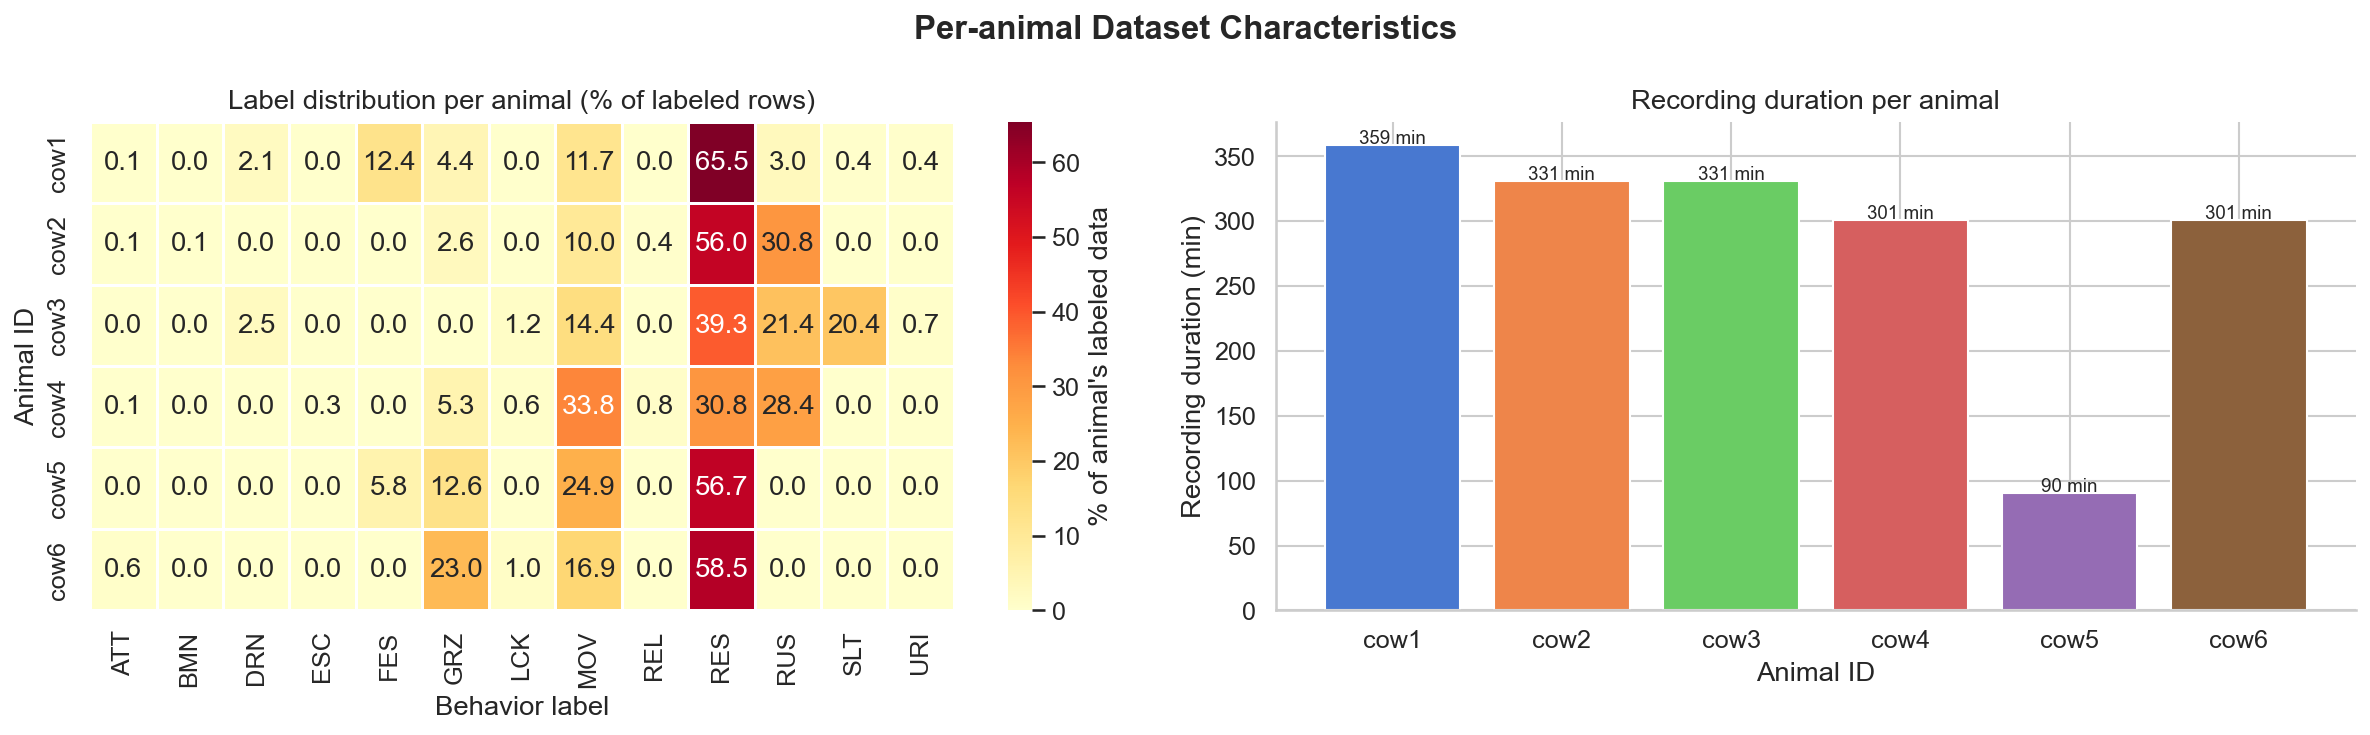

In [23]:
# ── Per-cow label distribution (heatmap) ─────────────────────────────────
filtered = raw[~raw["Label"].isin(EXCLUDED_LABELS)].copy() # only keep rows with valid labels for this analysis
pivot = (
    filtered.groupby(["animal_id","Label"])
    .size()
    .unstack(fill_value=0)
) 
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(
    pivot_pct, annot=True, fmt=".1f", cmap="YlOrRd",
    linewidths=0.5, ax=axes[0], cbar_kws={"label": "% of animal's labeled data"},
)
axes[0].set_title("Label distribution per animal (% of labeled rows)")
axes[0].set_xlabel("Behavior label")
axes[0].set_ylabel("Animal ID")

# ── Recording duration per animal ─────────────────────────────────────────
axes[1].bar(summary.index, summary["duration_min"], color=sns.color_palette("muted",6))
axes[1].set_ylabel("Recording duration (min)")
axes[1].set_title("Recording duration per animal")
axes[1].set_xlabel("Animal ID")
for i, (idx, row) in enumerate(summary.iterrows()):
    axes[1].text(i, row.duration_min+1, f"{row.duration_min:.0f} min",
                 ha="center", fontsize=9)
# How this for loop works:
# - `enumerate(summary.iterrows())` gives us both the index `i` (0, 1, 2, ...) and the row data `row` for each animal.
# - `axes[1].text(...)` places a text label on the bar chart:
#   - `i` is the x-coordinate (the position of the bar).
#   - `row.duration_min + 1` is the y-coordinate (just above the bar).
#   - `f"{row.duration_min:.0f} min"` formats the duration as an integer followed by "min".
#   - `ha="center"` centers the text horizontally on the bar.
#   - `fontsize=9` sets the font size of the label.
plt.suptitle("Per-animal Dataset Characteristics", fontweight="bold")
plt.tight_layout()
plt.show()


`The charts above need to be interpreted.`

In [24]:
print(len(filtered))

295674


### 📌 Interpretation
- **Unequal durations** across animals are common in field studies — the LOAO protocol handles this naturally since each fold uses a different test animal.  
- **Unequal label distributions** between animals (e.g., cow4 spends more time lying than cow1) is the core challenge: the classifier must generalize across individual behavioral patterns.  
- If one animal dominates a particular class, that class performance in its LOAO fold will be an upper bound — while its absence in other folds creates a lower bound.  
- Animals with very short recordings will produce fewer test windows in their LOAO fold → higher variance in fold-level accuracy estimates.


## 5. Raw Signal Visualization <a id='5'></a>

We visualize a continuous segment of the raw 25 Hz signal with color-coded behavior annotations.


In [25]:
LABEL_COLORS = {
    "BLN": "#CCCCCC", "ETC": "#AAAAAA",
    "LIE":"#4A90D9","LYI":"#4A90D9","LSL":"#6AAAE8","LFA":"#2070C0","LRU":"#1050A0",
    "STA":"#7DB87A","STD":"#7DB87A","SRU":"#5D9858","GRA":"#9DD89A","GRZ":"#9DD89A",
    "WAL":"#F5A623","WLK":"#F5A623",
    "RUN":"#D0021B","TRO":"#FF3333",
}

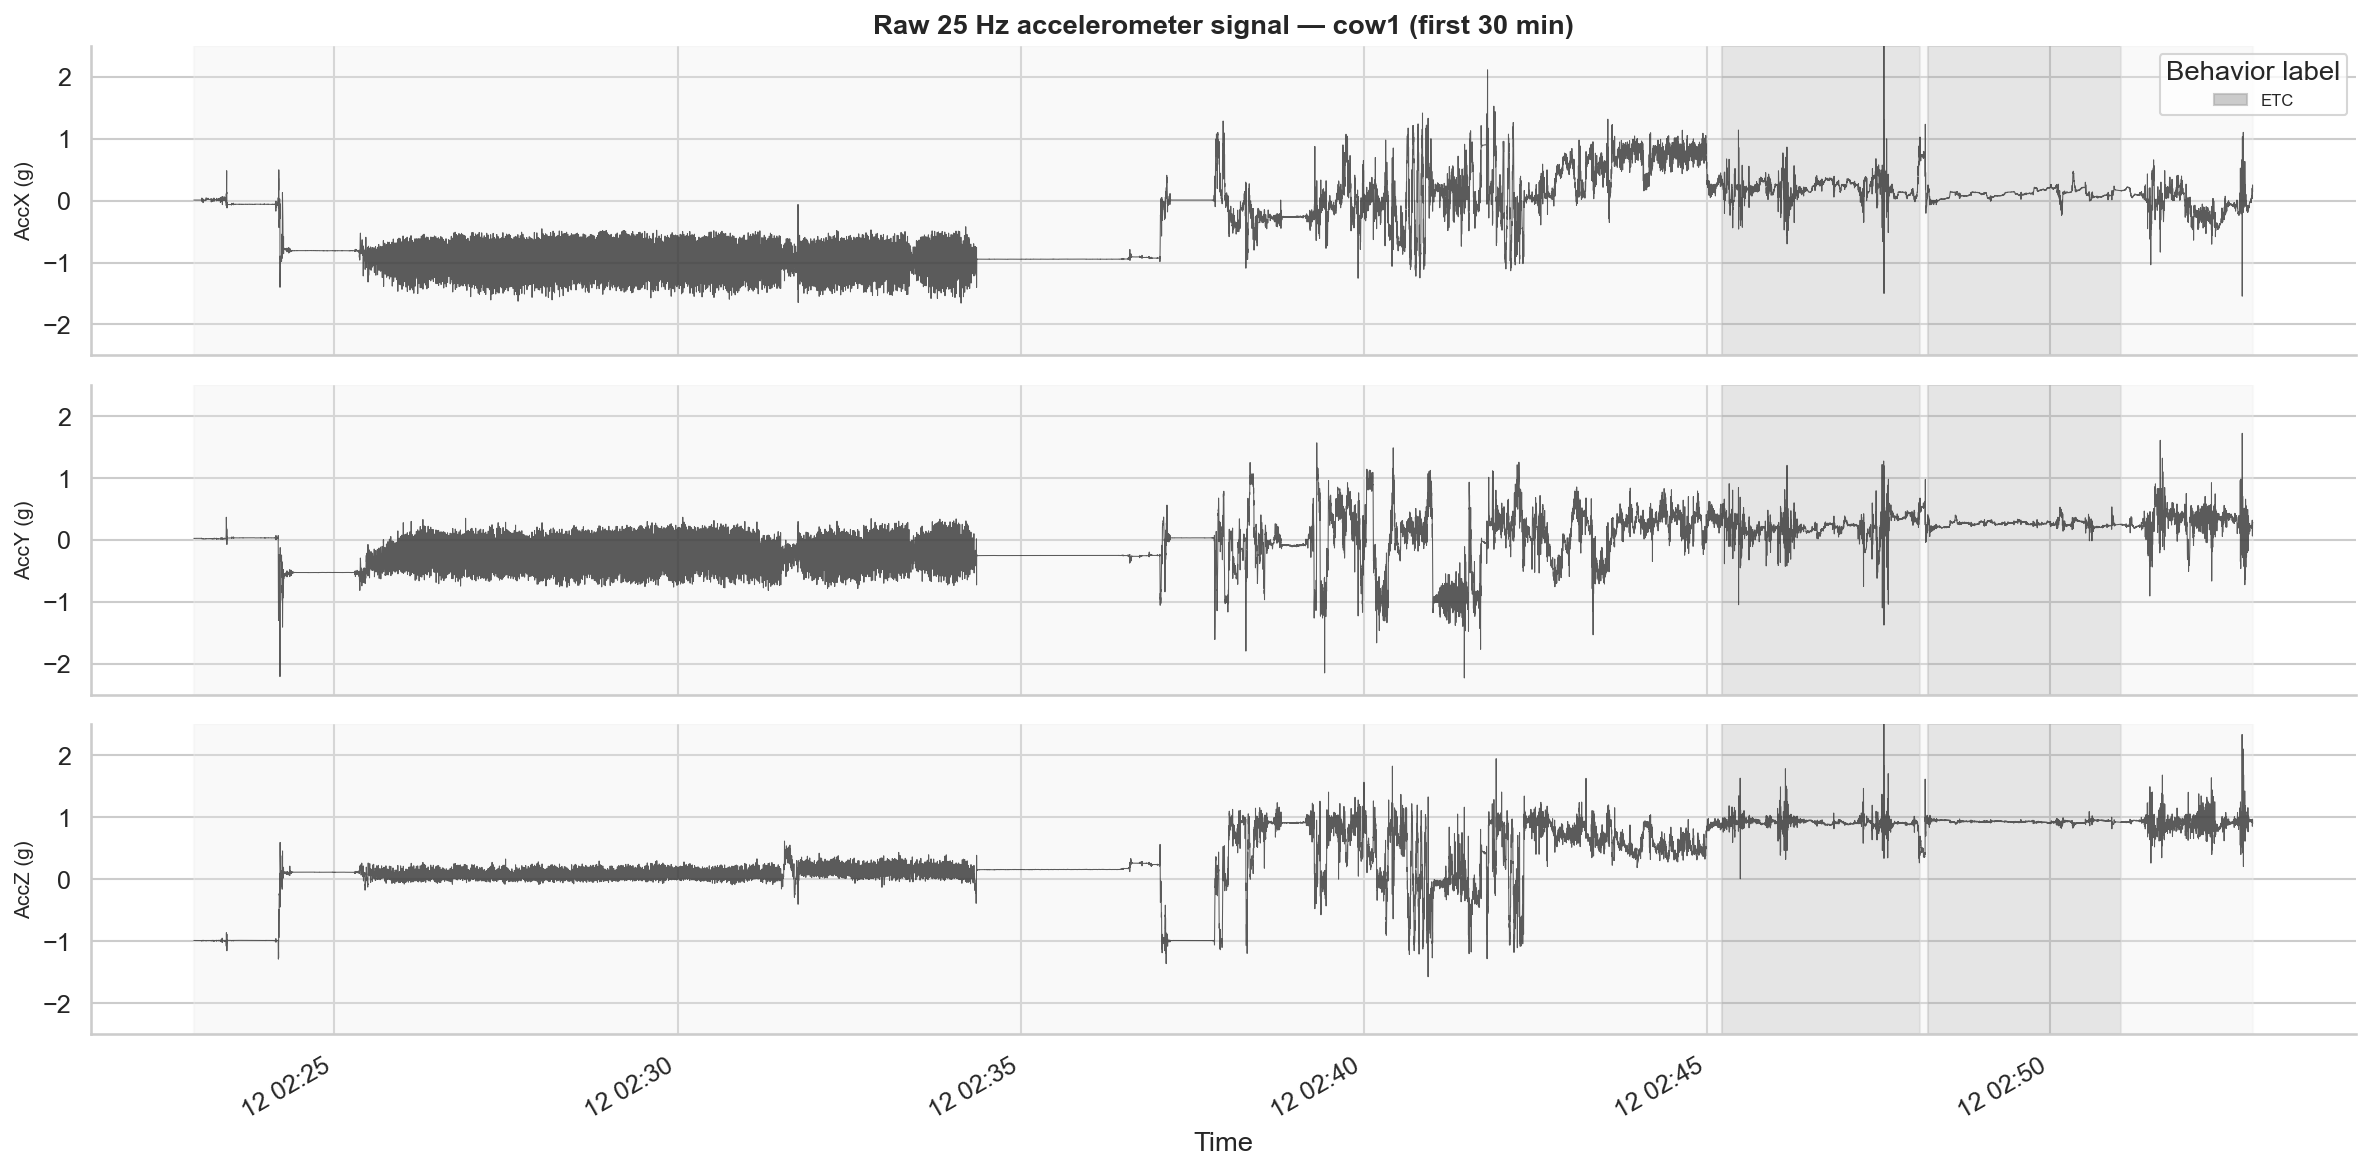

In [26]:
# Pick cow1 and show first 30 minutes
sample_cow = raw[raw["animal_id"]=="cow1"].copy().reset_index(drop=True) # reset index is for easier slicing and plotting, that is to say we want the first 30 minutes from the start of this cow's recording, so having a clean index helps with that
mask_30min  = sample_cow["datetime"] <= sample_cow["datetime"].iloc[0] + pd.Timedelta(minutes=30) # this creates a boolean mask that is True for rows where the datetime is within the first 30 minutes from the start of this cow's recording
segment     = sample_cow[mask_30min]

fig, axes = plt.subplots(3, 1, figsize=(16, 8), sharex=True)
axes_map = {"AccX": 0, "AccY": 1, "AccZ": 2} # to easily map axis names to subplot indices, that is to say we can loop through the axis names and know which subplot index to plot on

# The following loop iterates through the accelerometer axes (AccX, AccY, AccZ) and their corresponding subplot axes. 
# For each axis, it plots the accelerometer data over time for the selected segment of cow1's recording. 
# It also sets the y-axis label to indicate which accelerometer axis is being plotted and limits the y-axis range to between -2.5 and 2.5 g to ensure 
# that the data points are displayed within a consistent scale across all three subplots.
for axis, ax in zip(["AccX","AccY","AccZ"], axes): #zip is for looping through the axis names and their corresponding subplot axes
    ax.plot(segment["datetime"], segment[axis], lw=0.5, color="#333333", alpha=0.8) # lw stands for line width, and alpha controls the transparency of the line
    ax.set_ylabel(f"{axis} (g)", fontsize=10)
    ax.set_ylim(-2.5, 2.5)

# Color spans per label
prev_label = None
span_start = None
for _, row in segment.iterrows():
    lbl = row["Label"]
    if lbl != prev_label:
        if prev_label is not None:
            for ax in axes:
                ax.axvspan(span_start, row["datetime"], color=LABEL_COLORS.get(prev_label,"#EEEEEE"), alpha=0.3)
        span_start = row["datetime"]
        prev_label = lbl
# Close last span
if prev_label is not None:
    for ax in axes:
        ax.axvspan(span_start, segment["datetime"].iloc[-1],
                   color=LABEL_COLORS.get(prev_label,"#EEEEEE"), alpha=0.3)

from matplotlib.patches import Patch # this library is used to create custom legend handles (colored boxes) for the behavior labels in the plot legend. 
# Each Patch corresponds to a unique behavior label and is colored according to the LABEL_COLORS mapping, allowing us to visually associate the colors in the plot with their respective behavior labels in the legend.
unique_lbls = segment["Label"].unique()
legend_handles = [Patch(color=LABEL_COLORS.get(l,"#EEE"), label=l, alpha=0.6) for l in unique_lbls if l]
axes[0].legend(handles=legend_handles, loc="upper right", ncol=4, fontsize=8, title="Behavior label")

axes[0].set_title("Raw 25 Hz accelerometer signal — cow1 (first 30 min)", fontweight="bold")
axes[2].set_xlabel("Time")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()
# Summary: This chart is called a "raw accelerometer signal plot" and it shows the raw accelerometer data (AccX, AccY, AccZ) for cow1's first 30 minutes of recording. 
# Each subplot corresponds to one of the three accelerometer axes, and the shaded background colors indicate different behavior labels (e.g., lying, standing, walking) over time. 
# The legend on the top right helps to identify which colors correspond to which behavior labels. This type of plot is useful for visually inspecting the relationship 
# between the accelerometer signals and the annotated behaviors, as well as for identifying any patterns or anomalies in the data.

### 📌 Interpretation
- The **Z axis dominates the gravity component** (≈ −1 g at rest), while X and Y capture horizontal dynamics.  
- **Lying** periods show very low variance across all axes — the sensor barely moves.  
- **Walking/Running** introduce periodic oscillations, particularly visible in Y (lateral body sway) and X (fore-aft acceleration).  
- BLN (gray) segments often correspond to **transitions** between labeled behaviors — this validates our decision to exclude them from training.


## 6. Behavior-specific Signal Patterns <a id='6'></a>

Plotting one representative 5-second excerpt per simplified behavior class allows us to visually validate that the 4 classes are separable in the raw signal.


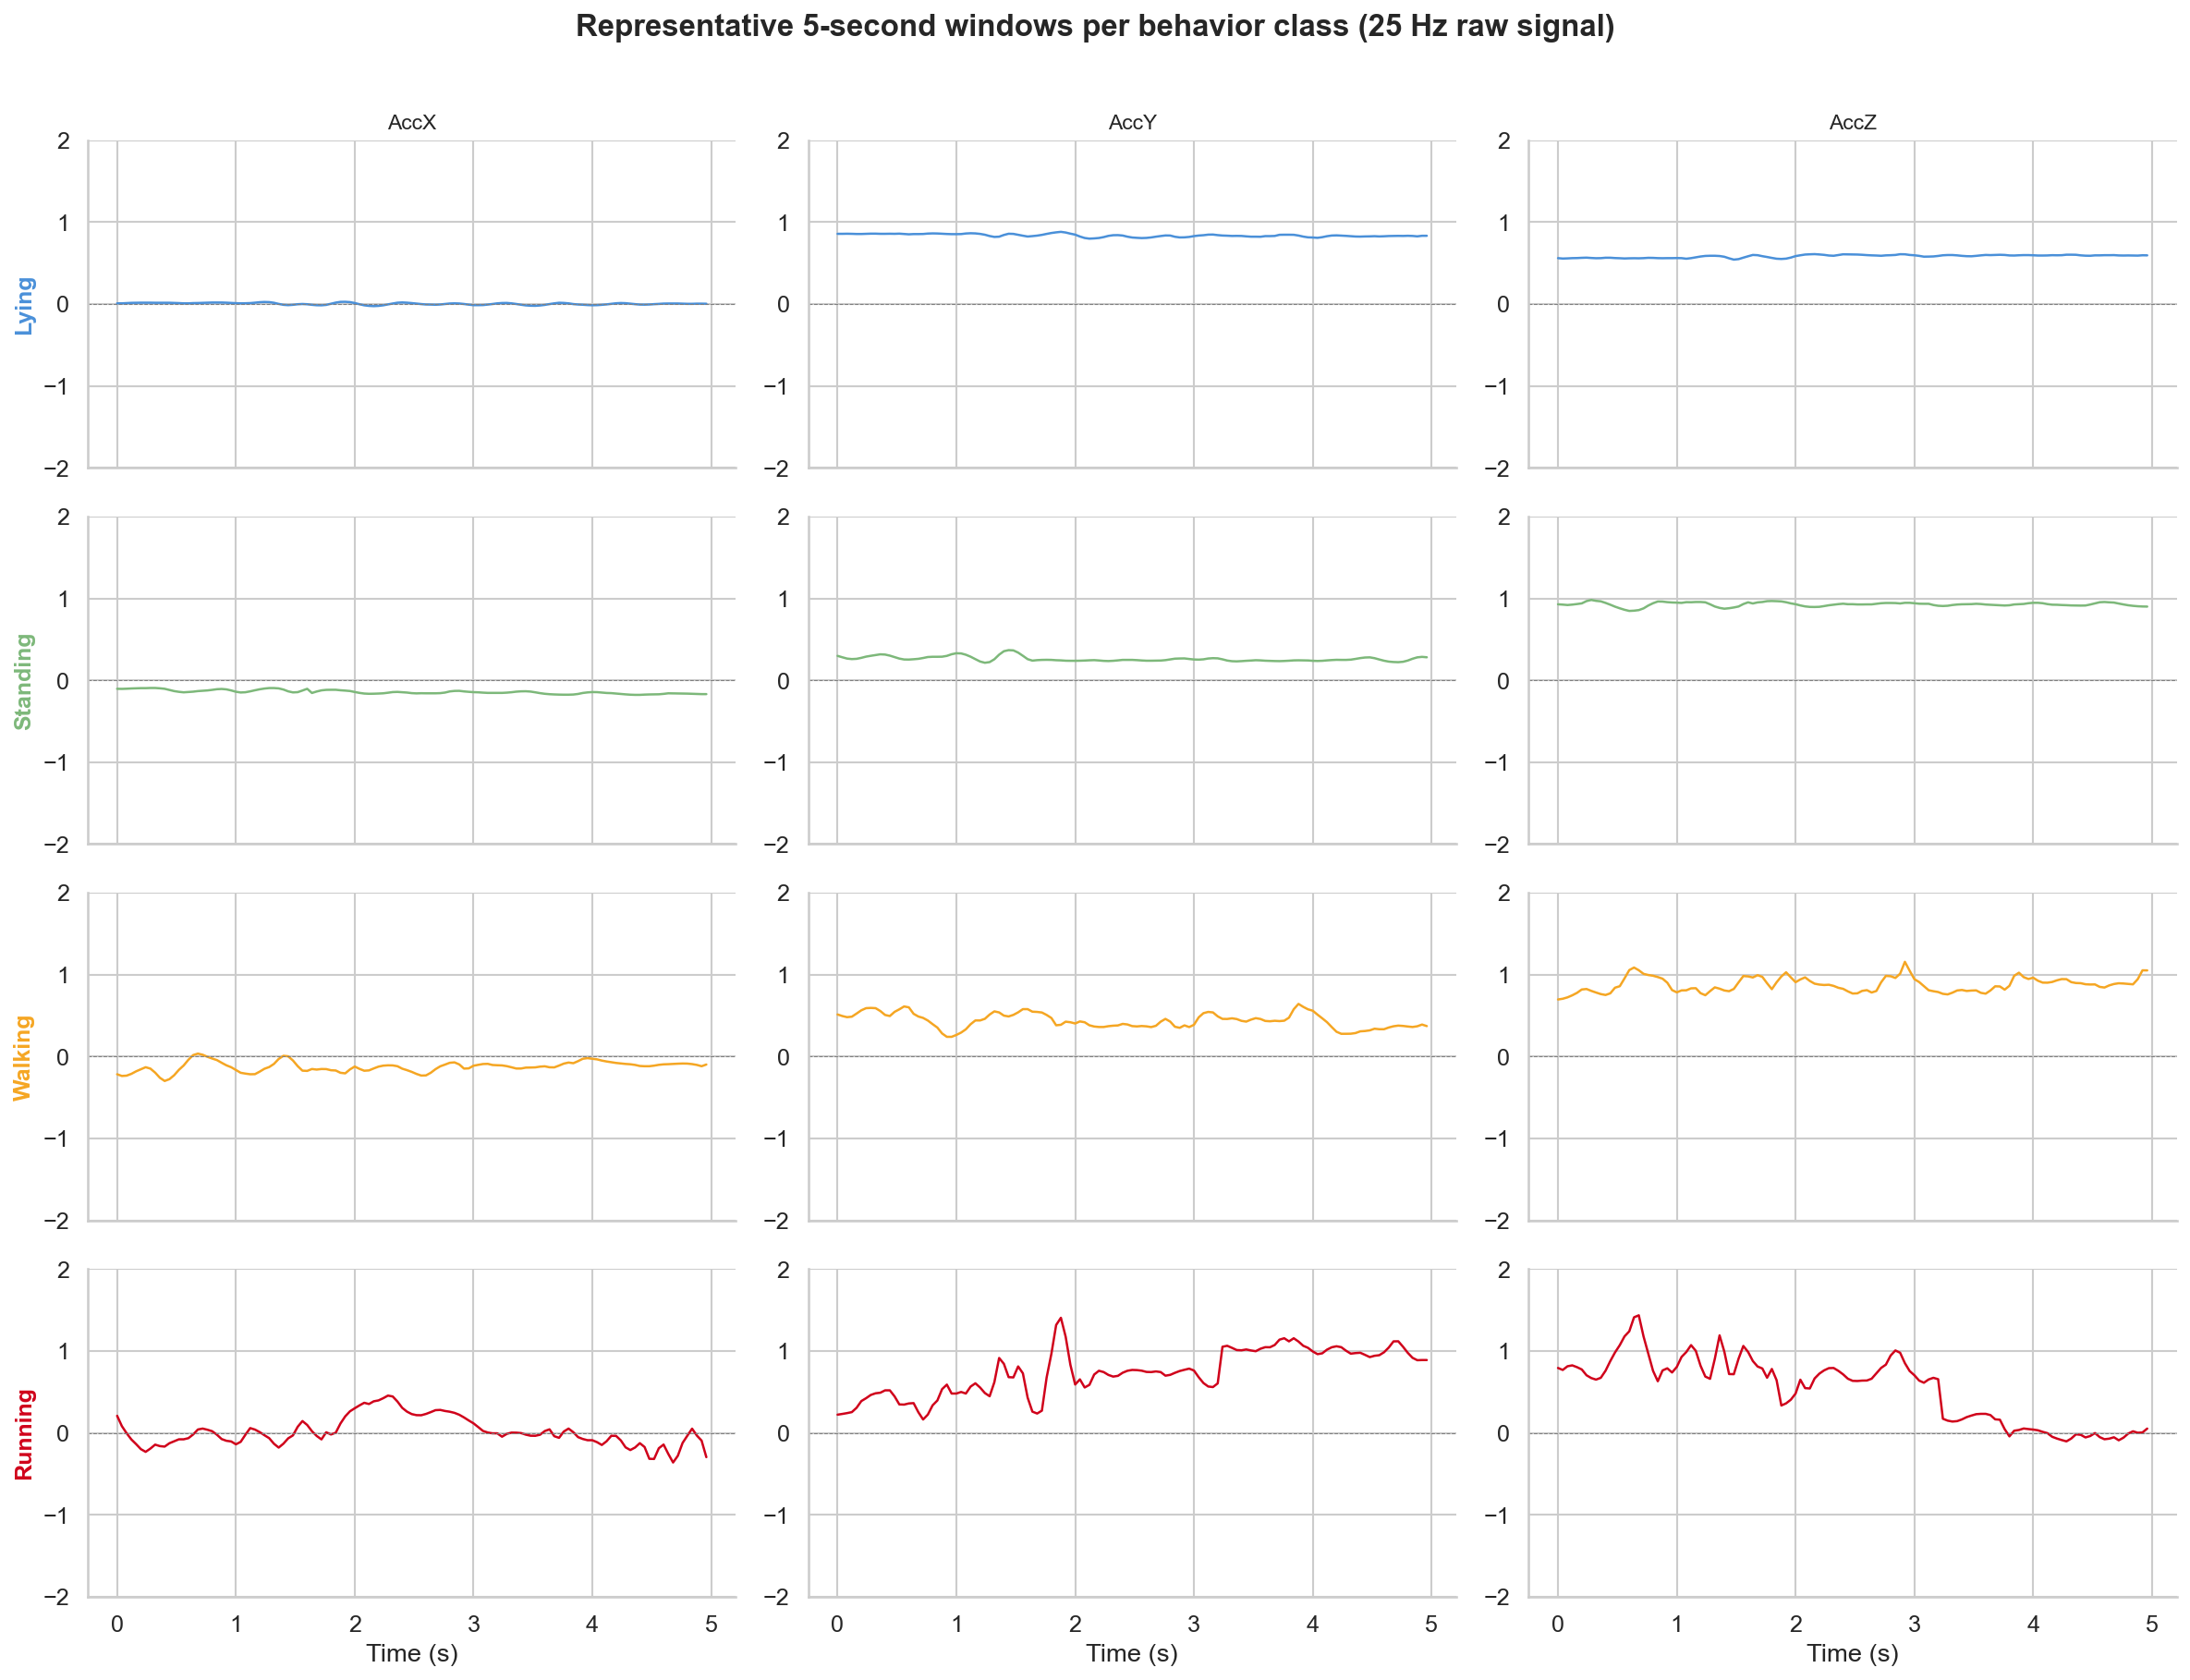

In [27]:
fig, axes = plt.subplots(4, 3, figsize=(16, 12), sharex=True)
filtered_raw = raw[~raw["Label"].isin(EXCLUDED_LABELS)].copy()
filtered_raw["simplified"] = filtered_raw["Label"].map(BEHAVIOR_MAP)
filtered_raw = filtered_raw.dropna(subset=["simplified"])

WINDOW_RAW = ORIGINAL_FREQ * WINDOW_SECONDS   # 125 samples at 25 Hz = 5 s

for row_idx, (beh, color) in enumerate(BEHAVIOR_PALETTE.items()):
    subset = filtered_raw[filtered_raw["simplified"] == beh]
    if len(subset) < WINDOW_RAW:
        for col_idx, axis in enumerate(["AccX","AccY","AccZ"]):
            axes[row_idx, col_idx].text(0.5, 0.5, "Not enough data", ha="center", va="center", transform=axes[row_idx,col_idx].transAxes)
            # 'Not enough data' message is displayed in the subplot when there are not enough samples for a given behavior class to plot a 5-second window of raw accelerometer data. 
            # This helps to indicate that the absence of a plot for that behavior is due to insufficient data rather than an error in the code. 
            # For example if only the standing chart is displayed, that means there were not enough samples for the other behaviors to plot a 5-second window of raw data.
        continue
    # Pick a contiguous block from the middle of the first long run
    # (avoid edge effects at label transitions)
    excerpt = subset.iloc[WINDOW_RAW:WINDOW_RAW*2] if len(subset) >= WINDOW_RAW*2 else subset.iloc[:WINDOW_RAW]
    t = np.arange(len(excerpt)) / ORIGINAL_FREQ

    for col_idx, axis in enumerate(["AccX","AccY","AccZ"]):
        ax = axes[row_idx, col_idx]
        ax.plot(t, excerpt[axis].values, color=color, lw=1.2)
        ax.set_ylim(-2, 2)
        ax.axhline(0, color="gray", lw=0.5, ls="--")
        if col_idx == 0:
            ax.set_ylabel(beh.capitalize(), fontsize=12, color=color, fontweight="bold")
        if row_idx == 0:
            ax.set_title(axis, fontsize=11)
        if row_idx == 3:
            ax.set_xlabel("Time (s)")

plt.suptitle("Representative 5-second windows per behavior class (25 Hz raw signal)",
            fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


### 📌 Interpretation 
<span style="color:red"> False</span>
| Behavior | AccX | AccY | AccZ | Dominant signature |
|----------|------|------|------|--------------------|
| **Lying** | ≈ 0 g, flat | ≈ 0 g, flat | ≈ −1 g, flat | Near-zero variance everywhere |
| **Standing** | Low variance | Low variance | ≈ −1 g | Slight sway (rumination micro-movements) |
| **Walking** | Rhythmic ±0.3 g | Lateral sway | Oscillating | Clear periodic pattern at stride frequency |
| **Running** | High amplitude, chaotic | High amplitude | Large excursions | High variance, saturating peaks |

These visual differences justify the 12-feature statistical approach (mean, std, min, max per axis):
- **std** is the primary discriminator between lying and active states.
- **min/max** captures the peak forces during running.
- **mean** of AccZ reflects body tilt angle (standing vs. lying posture change).


## 7. Downsampling 25 Hz → 10 Hz <a id='7'></a>

The M5Stack hardware samples at 10 Hz. We downsample the reference dataset to match,
using 100 ms bin averaging. Here we verify that the signal structure is preserved.


In [28]:
raw["Label"].unique()

<StringArray>
[   '', 'ETC', 'RES', 'URI', 'MOV', 'ATT', 'FES', 'GRZ', 'RUS', 'DRN', 'SLT',
 'REL', 'BMN', 'LCK', 'ESC']
Length: 15, dtype: str

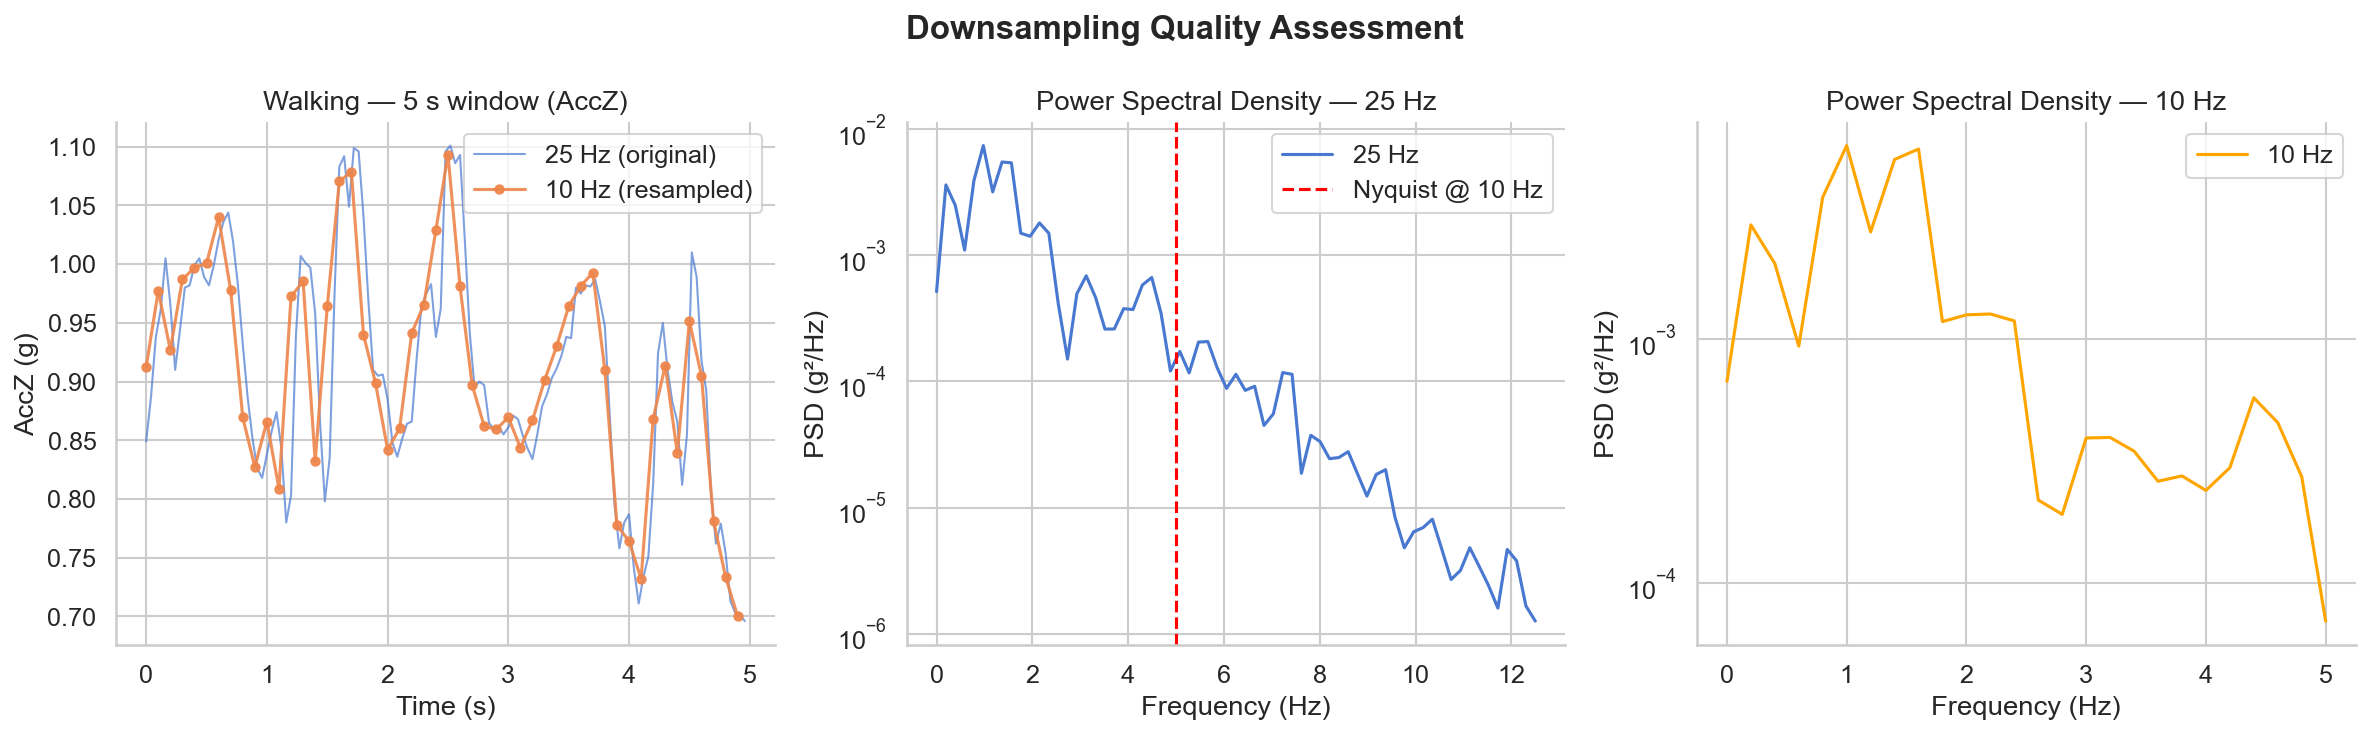

Rows before downsampling (cow1) : 311,876
Rows after  downsampling (cow1) : 215,310
Expected ratio                  : 2.5x  |  Actual ratio: 1.45x
********************
Lignes 'MOV' à 25Hz : 6376
Lignes 'MOV' à 10Hz : 2545


In [29]:
# Downsample cow1 for visual comparison
cow1_raw = raw[raw["animal_id"]=="cow1"].copy()
cow1_raw["datetime"] = pd.to_datetime(cow1_raw["TimeStamp_UNIX"], unit="ms")
cow1_raw = cow1_raw.set_index("datetime").sort_index()

cow1_10hz = cow1_raw[["AccX","AccY","AccZ","Label"]].resample("100ms").agg(
    {"AccX":"mean","AccY":"mean","AccZ":"mean",
     "Label": lambda s: s.mode().iloc[0] if len(s)>0 else ""}
)

# Power spectral density comparison (AccZ, walking segment)
walk_raw = raw[(raw["animal_id"]=="cow1") & (raw["Label"] == "MOV")].reset_index(drop=True)
walk_10hz = cow1_10hz[cow1_10hz["Label"] == "MOV"].reset_index(drop=True)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── A: 5-second overlay ───────────────────────────────────────────────────
if len(walk_raw) >= 125:
    t25 = np.arange(125) / 25
    t10 = np.arange(50) / 10
    axes[0].plot(t25, walk_raw["AccZ"].iloc[:125].values, label="25 Hz (original)", alpha=0.7, lw=1)
    axes[0].plot(t10, walk_10hz["AccZ"].iloc[:50].values, "o-", label="10 Hz (resampled)", alpha=0.9, lw=1.5, ms=4)
    axes[0].set_xlabel("Time (s)")
    axes[0].set_ylabel("AccZ (g)")
    axes[0].set_title("Walking — 5 s window (AccZ)")
    axes[0].legend()

# ── B: PSD at 25 Hz ──────────────────────────────────────────────────────
if len(walk_raw) >= 500:
    # Use .values to avoid the pandas KeyError
    f25, P25 = sp_signal.welch(walk_raw["AccZ"].iloc[:500].values, fs=25, nperseg=128)
    axes[1].semilogy(f25, P25, label="25 Hz")
    axes[1].axvline(5, color="red", ls="--", label="Nyquist @ 10 Hz")
    axes[1].set_xlabel("Frequency (Hz)")
    axes[1].set_ylabel("PSD (g²/Hz)")
    axes[1].set_title("Power Spectral Density — 25 Hz")
    axes[1].legend()

# ── C: PSD at 10 Hz ──────────────────────────────────────────────────────
if len(walk_10hz) >= 200:
    # Use .values here as well
    f10, P10 = sp_signal.welch(walk_10hz["AccZ"].iloc[:200].values, fs=10, nperseg=50)
    axes[2].semilogy(f10, P10, color="orange", label="10 Hz")
    axes[2].set_xlabel("Frequency (Hz)")
    axes[2].set_ylabel("PSD (g²/Hz)")
    axes[2].set_title("Power Spectral Density — 10 Hz")
    axes[2].legend()

plt.suptitle("Downsampling Quality Assessment", fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Rows before downsampling (cow1) : {len(cow1_raw):,}")
print(f"Rows after  downsampling (cow1) : {len(cow1_10hz):,}")
print(f"Expected ratio                  : {ORIGINAL_FREQ/TARGET_FREQ:.1f}x  |  "
      f"Actual ratio: {len(cow1_raw)/len(cow1_10hz):.2f}x")
print("**"*10)
# Debug : Vérifie si on a enfin des données
print(f"Lignes 'MOV' à 25Hz : {len(walk_raw)}")
print(f"Lignes 'MOV' à 10Hz : {len(walk_10hz)}")


In [30]:
# The above graph(Downsampling Quality Assessment) shows 3 empty charts because there are not enough samples for the walking behavior in cow1's recording to plot a 5-second window of raw accelerometer data at either 25 Hz or 10 Hz.
# The first chart (A) is supposed to show an overlay of a 5-second window of the AccZ signal for both the original 25 Hz data and the downsampled 10 Hz data during a walking segment. 
# However, since there are not enough samples for the walking behavior in cow1's recording, this chart will be empty. 
# The second and third charts (B and C) are supposed to show the power spectral density (PSD) of the AccZ signal for the walking segments at 25 Hz and 10 Hz, respectively.
# Again, due to the lack of sufficient walking data in cow1's recording, these charts will also be empty. 
# This highlights the importance of having enough labeled data for each behavior class when performing analyses like downsampling quality assessment, as insufficient data can limit our ability to evaluate the effects of preprocessing steps on specific behaviors.

### 📌 Interpretation
- The **Nyquist frequency at 10 Hz is 5 Hz** — any locomotion-related energy above this is aliased. In bovine gait, the fundamental stride frequency is 0.5–2 Hz, well within the 10 Hz band.  
- Mean aggregation in the 100 ms bin acts as a **low-pass filter**, preventing aliasing without explicit anti-aliasing filtering.  
- The PSD comparison should show that the dominant peaks (stride frequency and harmonics) are preserved after downsampling.  
- **Conclusion**: 10 Hz is sufficient for the 4-class problem. The M5Stack constraint does not compromise classification quality.


## 8. Feature Extraction <a id='8'></a>

We reproduce the full feature extraction pipeline from `train.py` and create the feature matrix used for ML.


In [33]:
def downsample_all(df):
    parts = []
    for animal_id, group in df.groupby("animal_id"):
        group = group.copy()
        group["datetime"] = pd.to_datetime(group["TimeStamp_UNIX"], unit="ms")
        g = group.set_index("datetime").sort_index()
        acc = g[["AccX","AccY","AccZ"]].resample("100ms").mean()
        lbl = g["Label"].resample("100ms").agg(
            lambda s: s.mode().iloc[0] if len(s)>0 else ""
        )
        r = acc.copy()
        r["Label"]     = lbl
        r["animal_id"] = animal_id
        r = r.dropna(subset=["AccX","AccY","AccZ"]).reset_index(drop=True)
        parts.append(r)
    return pd.concat(parts, ignore_index=True)


def apply_windowing(df):
    records = []
    for animal_id, group in df.groupby("animal_id"):
        group = group.reset_index(drop=True)
        n_win = len(group) // WINDOW_SAMPLES
        for i in range(n_win):
            w = group.iloc[i*WINDOW_SAMPLES:(i+1)*WINDOW_SAMPLES]
            lc = w["Label"].value_counts()
            maj = lc.index[0]
            if lc.iloc[0]/WINDOW_SAMPLES < LABEL_PURITY:
                continue
            if maj in EXCLUDED_LABELS:
                continue
            simplified = BEHAVIOR_MAP.get(maj)
            if simplified is None:
                continue
            r = {}
            for axis, col in [("x","AccX"),("y","AccY"),("z","AccZ")]:
                v = w[col].to_numpy()
                r[f"accel_{axis}_mean"] = np.mean(v)
                r[f"accel_{axis}_std"]  = np.std(v)
                r[f"accel_{axis}_min"]  = np.min(v)
                r[f"accel_{axis}_max"]  = np.max(v)
            r["label_simplified"] = simplified
            r["animal_id"]        = animal_id
            records.append(r)
    return pd.DataFrame(records)


print("Downsampling …")
df_10hz   = downsample_all(raw)
print("Windowing …")
df_windows = apply_windowing(df_10hz)

print(f"\nTotal windows: {len(df_windows):,}")
print(f"\nWindow count per behavior:")
print(df_windows["label_simplified"].value_counts().to_string())
print(f"\nWindow count per animal:")
print(df_windows["animal_id"].value_counts().sort_index().to_string())


Downsampling …
Windowing …

Total windows: 2,019

Window count per behavior:
label_simplified
standing    1732
walking      281
lying          6

Window count per animal:
animal_id
cow1    375
cow2    605
cow3    352
cow4    330
cow5    127
cow6    230


In [34]:
df_windows[FEATURE_COLUMNS].describe().round(4)

,accel_x_mean,accel_x_std,accel_x_min,accel_x_max,accel_y_mean,accel_y_std,accel_y_min,accel_y_max,accel_z_mean,accel_z_std,accel_z_min,accel_z_max
count,2019.0000,2019.0000,2019.0000,2019.0000,2019.0000,2019.0000,2019.0000,2019.0000,2019.0000,2019.0000,2019.0000,2019.0000
mean,-0.0630,0.0383,-0.1451,0.0279,0.7932,0.0509,0.6825,0.9090,0.4597,0.0392,0.3765,0.5520
std,0.1695,0.0526,0.1834,0.2390,0.2789,0.0951,0.3548,0.3333,0.3074,0.0721,0.3228,0.3669
min,-0.5025,0.0003,-1.5515,-0.4925,-0.7024,0.0005,-1.2877,-0.5383,-0.2950,0.0010,-1.3240,-0.0970
25%,-0.1364,0.0079,-0.2445,-0.0885,0.6194,0.0085,0.4495,0.7505,0.1709,0.0079,0.1266,0.2134
50%,-0.0573,0.0165,-0.0990,-0.0113,0.8854,0.0182,0.7860,1.0033,0.5140,0.0163,0.3030,0.5577
75%,-0.0029,0.0519,-0.0433,0.0942,1.0198,0.0543,0.9882,1.0633,0.7508,0.0446,0.6381,0.8747
max,0.6908,0.5003,0.4980,1.2770,1.0602,1.0193,1.0410,3.1450,0.9616,0.8958,0.9440,3.2450


## 9. Feature Distributions per Behavior <a id='9'></a>

Violin plots show the distribution shape of each of the 12 features split by behavior class.
Good features should exhibit clear separability between classes.


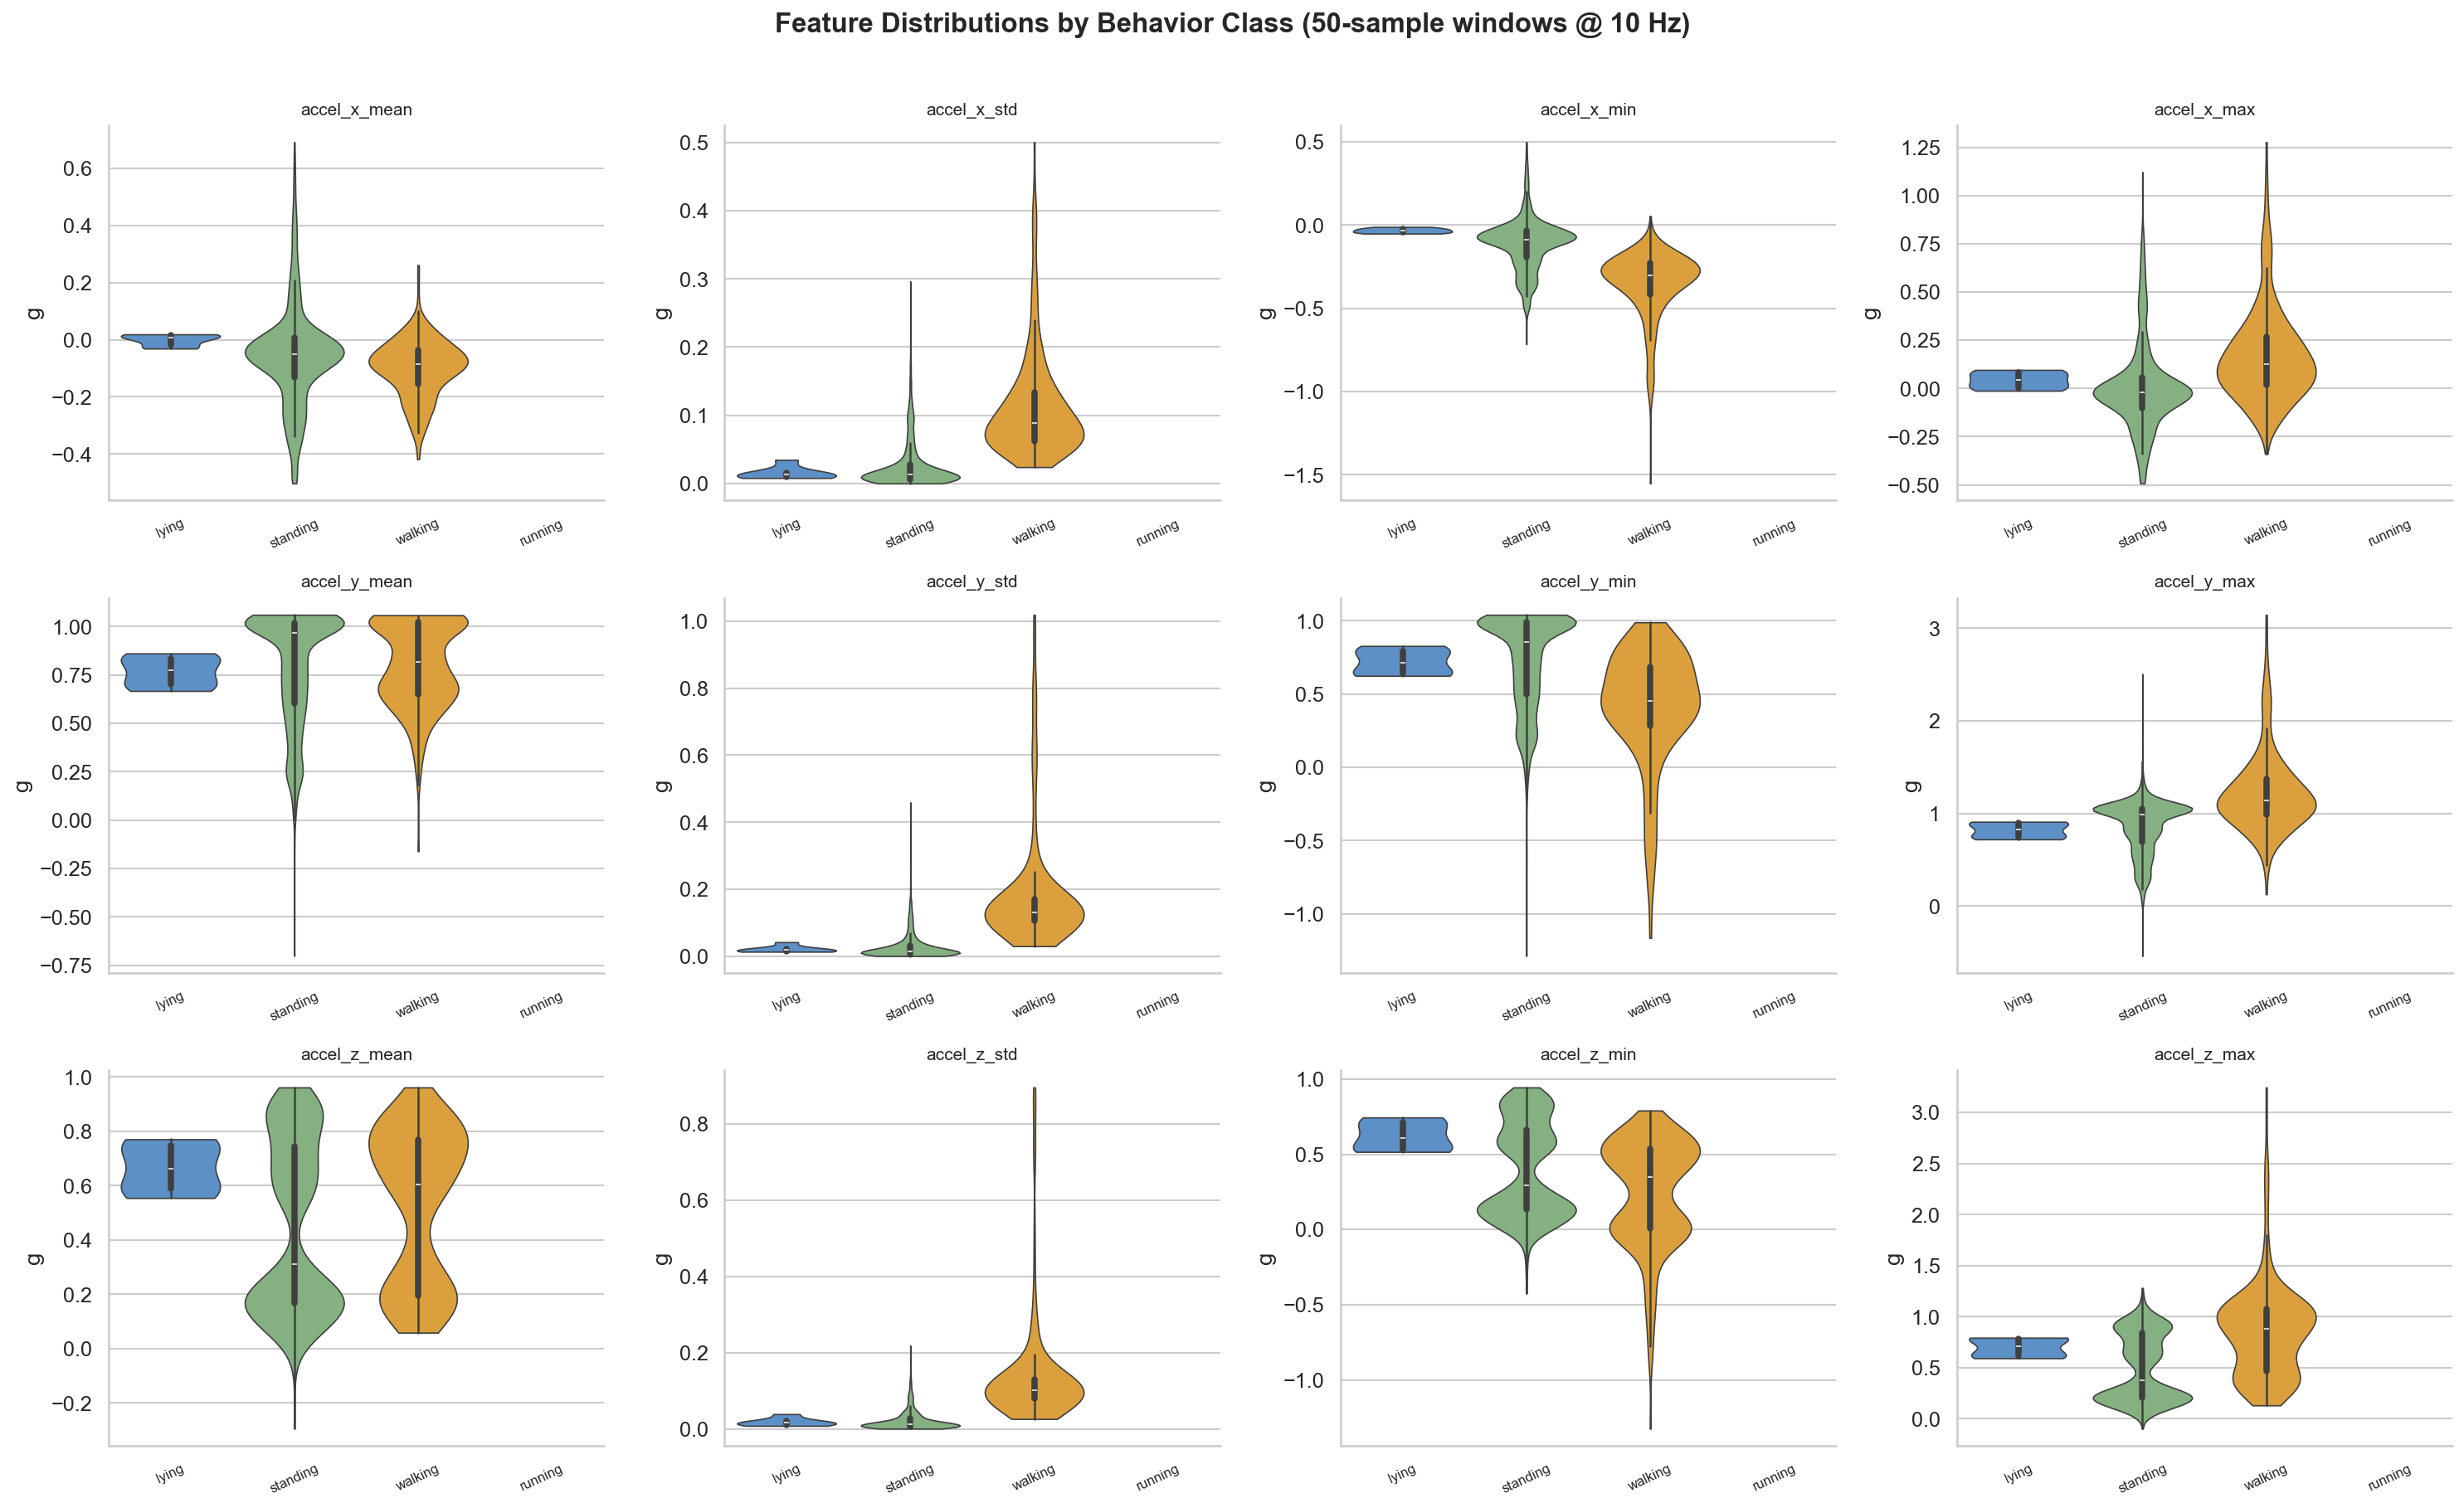

In [35]:
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()

for idx, feat in enumerate(FEATURE_COLUMNS):
    ax = axes[idx]
    order = SIMPLIFIED_STATES
    palette = BEHAVIOR_PALETTE
    sns.violinplot(
        data=df_windows, x="label_simplified", y=feat,
        order=order, palette=palette, ax=ax,
        inner="box", linewidth=0.8, cut=0,
    )
    ax.set_title(feat, fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("g" if "mean" in feat or "min" in feat or "max" in feat else "g")
    ax.tick_params(axis="x", rotation=25, labelsize=8)

plt.suptitle("Feature Distributions by Behavior Class (50-sample windows @ 10 Hz)",
             fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


### 📌 Interpretation

**High discriminative power:**
- `accel_z_mean` : Lying has a distinctly different mean (sensor tilted) vs. standing/walking.  
- `accel_x_std`, `accel_y_std`, `accel_z_std` : Near-zero for lying, progressively larger for standing → walking → running.  
- `accel_x_max`, `accel_z_max` : Running shows extreme values not present in other classes.  

**Lower discriminative power:**
- `accel_*_mean` for X/Y : Close to zero for all classes (near-symmetric oscillations average out).  

**Standing vs. Walking confusion risk:**
- The std features show partial overlap between standing and walking.  
- This is where the Random Forest's combination of multiple features becomes critical — no single feature cleanly separates these two classes.


## 10. Correlation Analysis <a id='10'></a>

High inter-feature correlation reduces the effective dimensionality of the feature space.
This does not hurt Random Forests (which use random feature subsets), but informs feature selection
for lighter TinyML models (Step 4 of the roadmap).


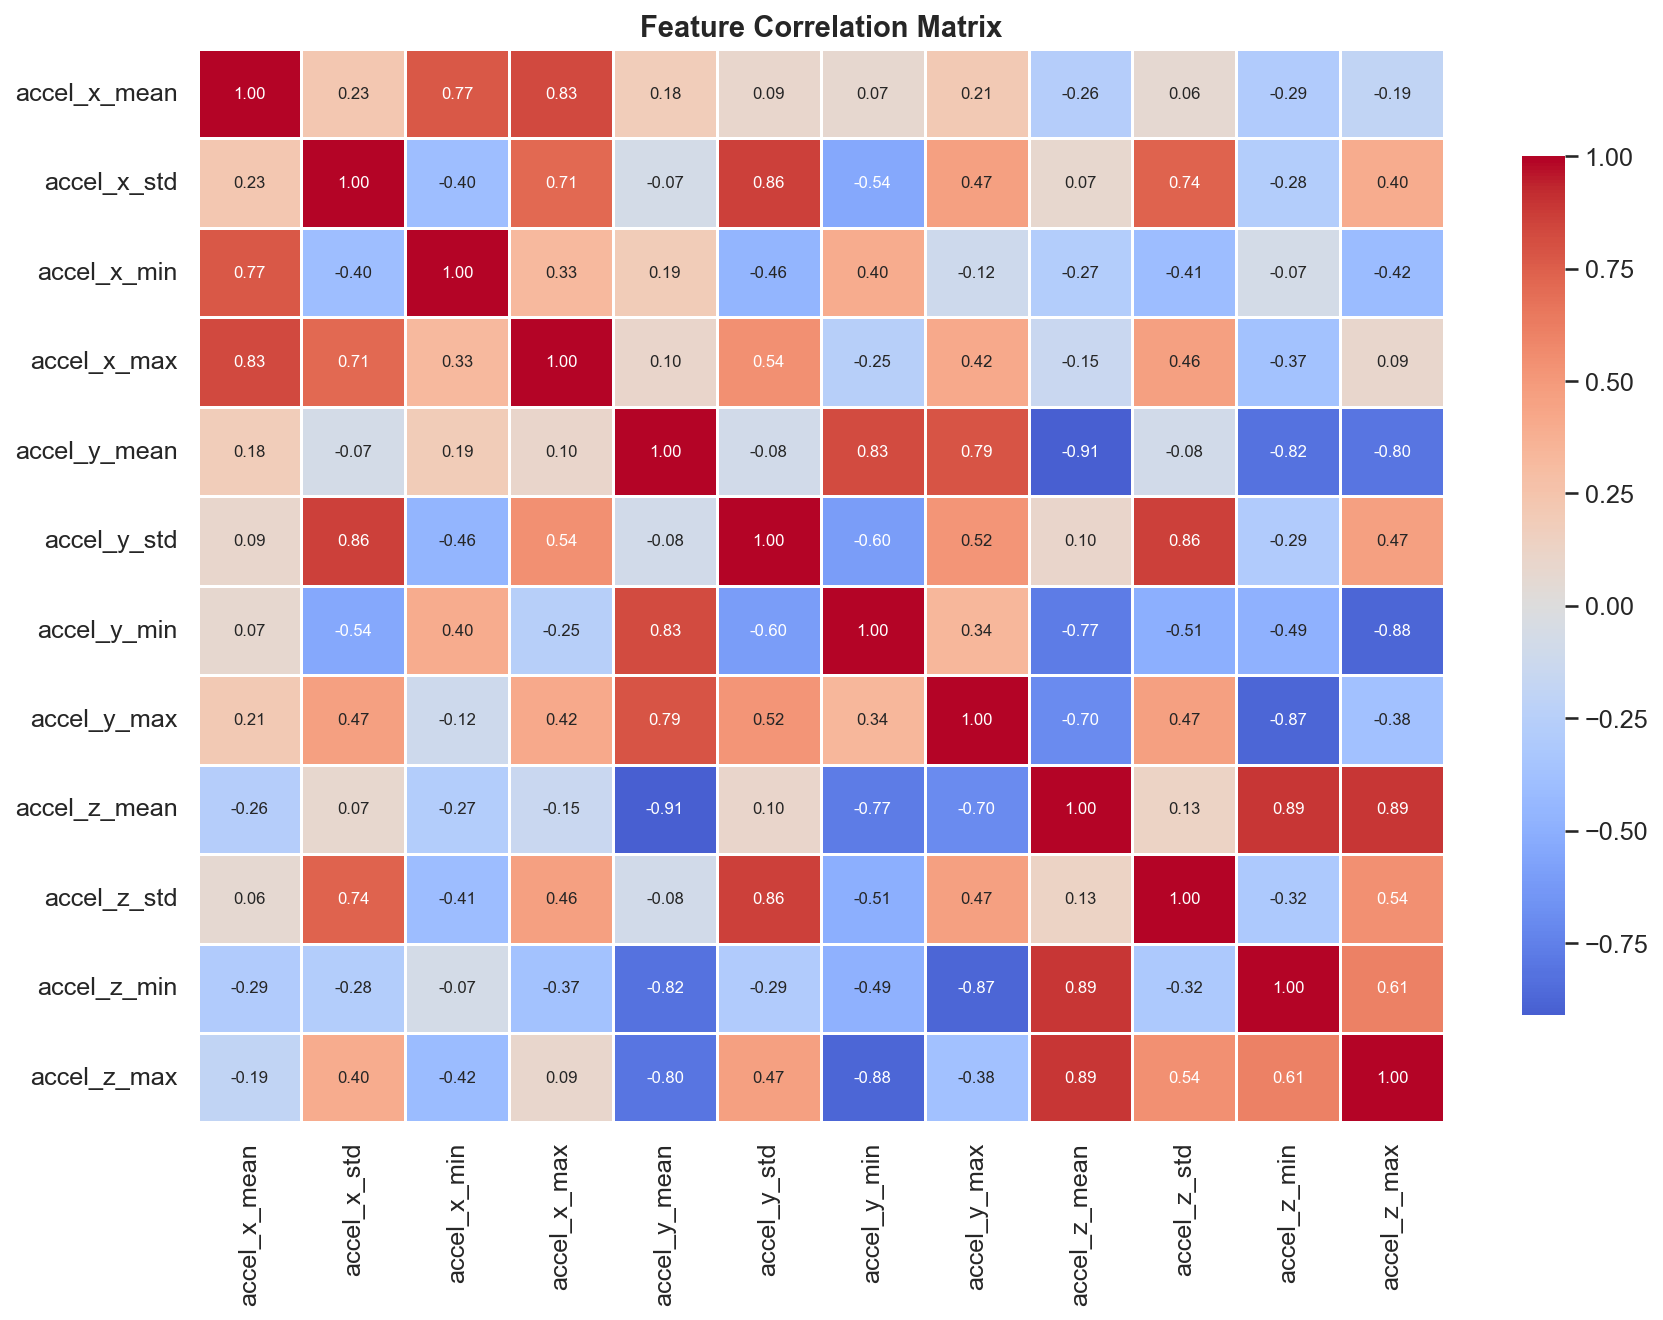

Top 10 most correlated feature pairs:
      feat_1       feat_2  correlation  abs_corr
accel_z_mean accel_y_mean    -0.910258  0.910258
 accel_z_max accel_z_mean     0.894989  0.894989
 accel_z_min accel_z_mean     0.890874  0.890874
 accel_z_max  accel_y_min    -0.876695  0.876695
 accel_z_min  accel_y_max    -0.874663  0.874663
 accel_y_std  accel_x_std     0.862048  0.862048
 accel_z_std  accel_y_std     0.859728  0.859728
 accel_x_max accel_x_mean     0.828531  0.828531
 accel_y_min accel_y_mean     0.827717  0.827717
 accel_z_min accel_y_mean    -0.823210  0.823210


In [36]:
corr = df_windows[FEATURE_COLUMNS].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(
    corr, annot=True, fmt=".2f", cmap="coolwarm",
    center=0, linewidths=0.5, ax=ax,
    annot_kws={"size": 8},
    cbar_kws={"shrink": 0.8},
)
ax.set_title("Feature Correlation Matrix", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.show()

# Top redundant pairs
corr_pairs = (
    corr.where(np.tril(np.ones(corr.shape), k=-1).astype(bool))
    .stack()
    .reset_index()
)
corr_pairs.columns = ["feat_1","feat_2","correlation"]
corr_pairs["abs_corr"] = corr_pairs["correlation"].abs()
print("Top 10 most correlated feature pairs:")
print(corr_pairs.sort_values("abs_corr", ascending=False).head(10).to_string(index=False))


### 📌 Interpretation
- **min/max are strongly correlated with std** within the same axis — both capture the amplitude of the signal.  
- **Cross-axis correlations** reflect the physical coupling of accelerations (e.g., a stride affects all 3 axes simultaneously).  
- For the **TinyML step (Step 4)**, this suggests that a 6-feature subset (mean + std per axis) might retain most predictive power while halving memory requirements on the ESP32.


## 11. Inter-animal Variability (LOAO perspective) <a id='11'></a>

The core assumption of LOAO is that animals differ enough that leaving one out provides a realistic
estimate of generalisation. Here we quantify between-animal variability per feature and behavior.


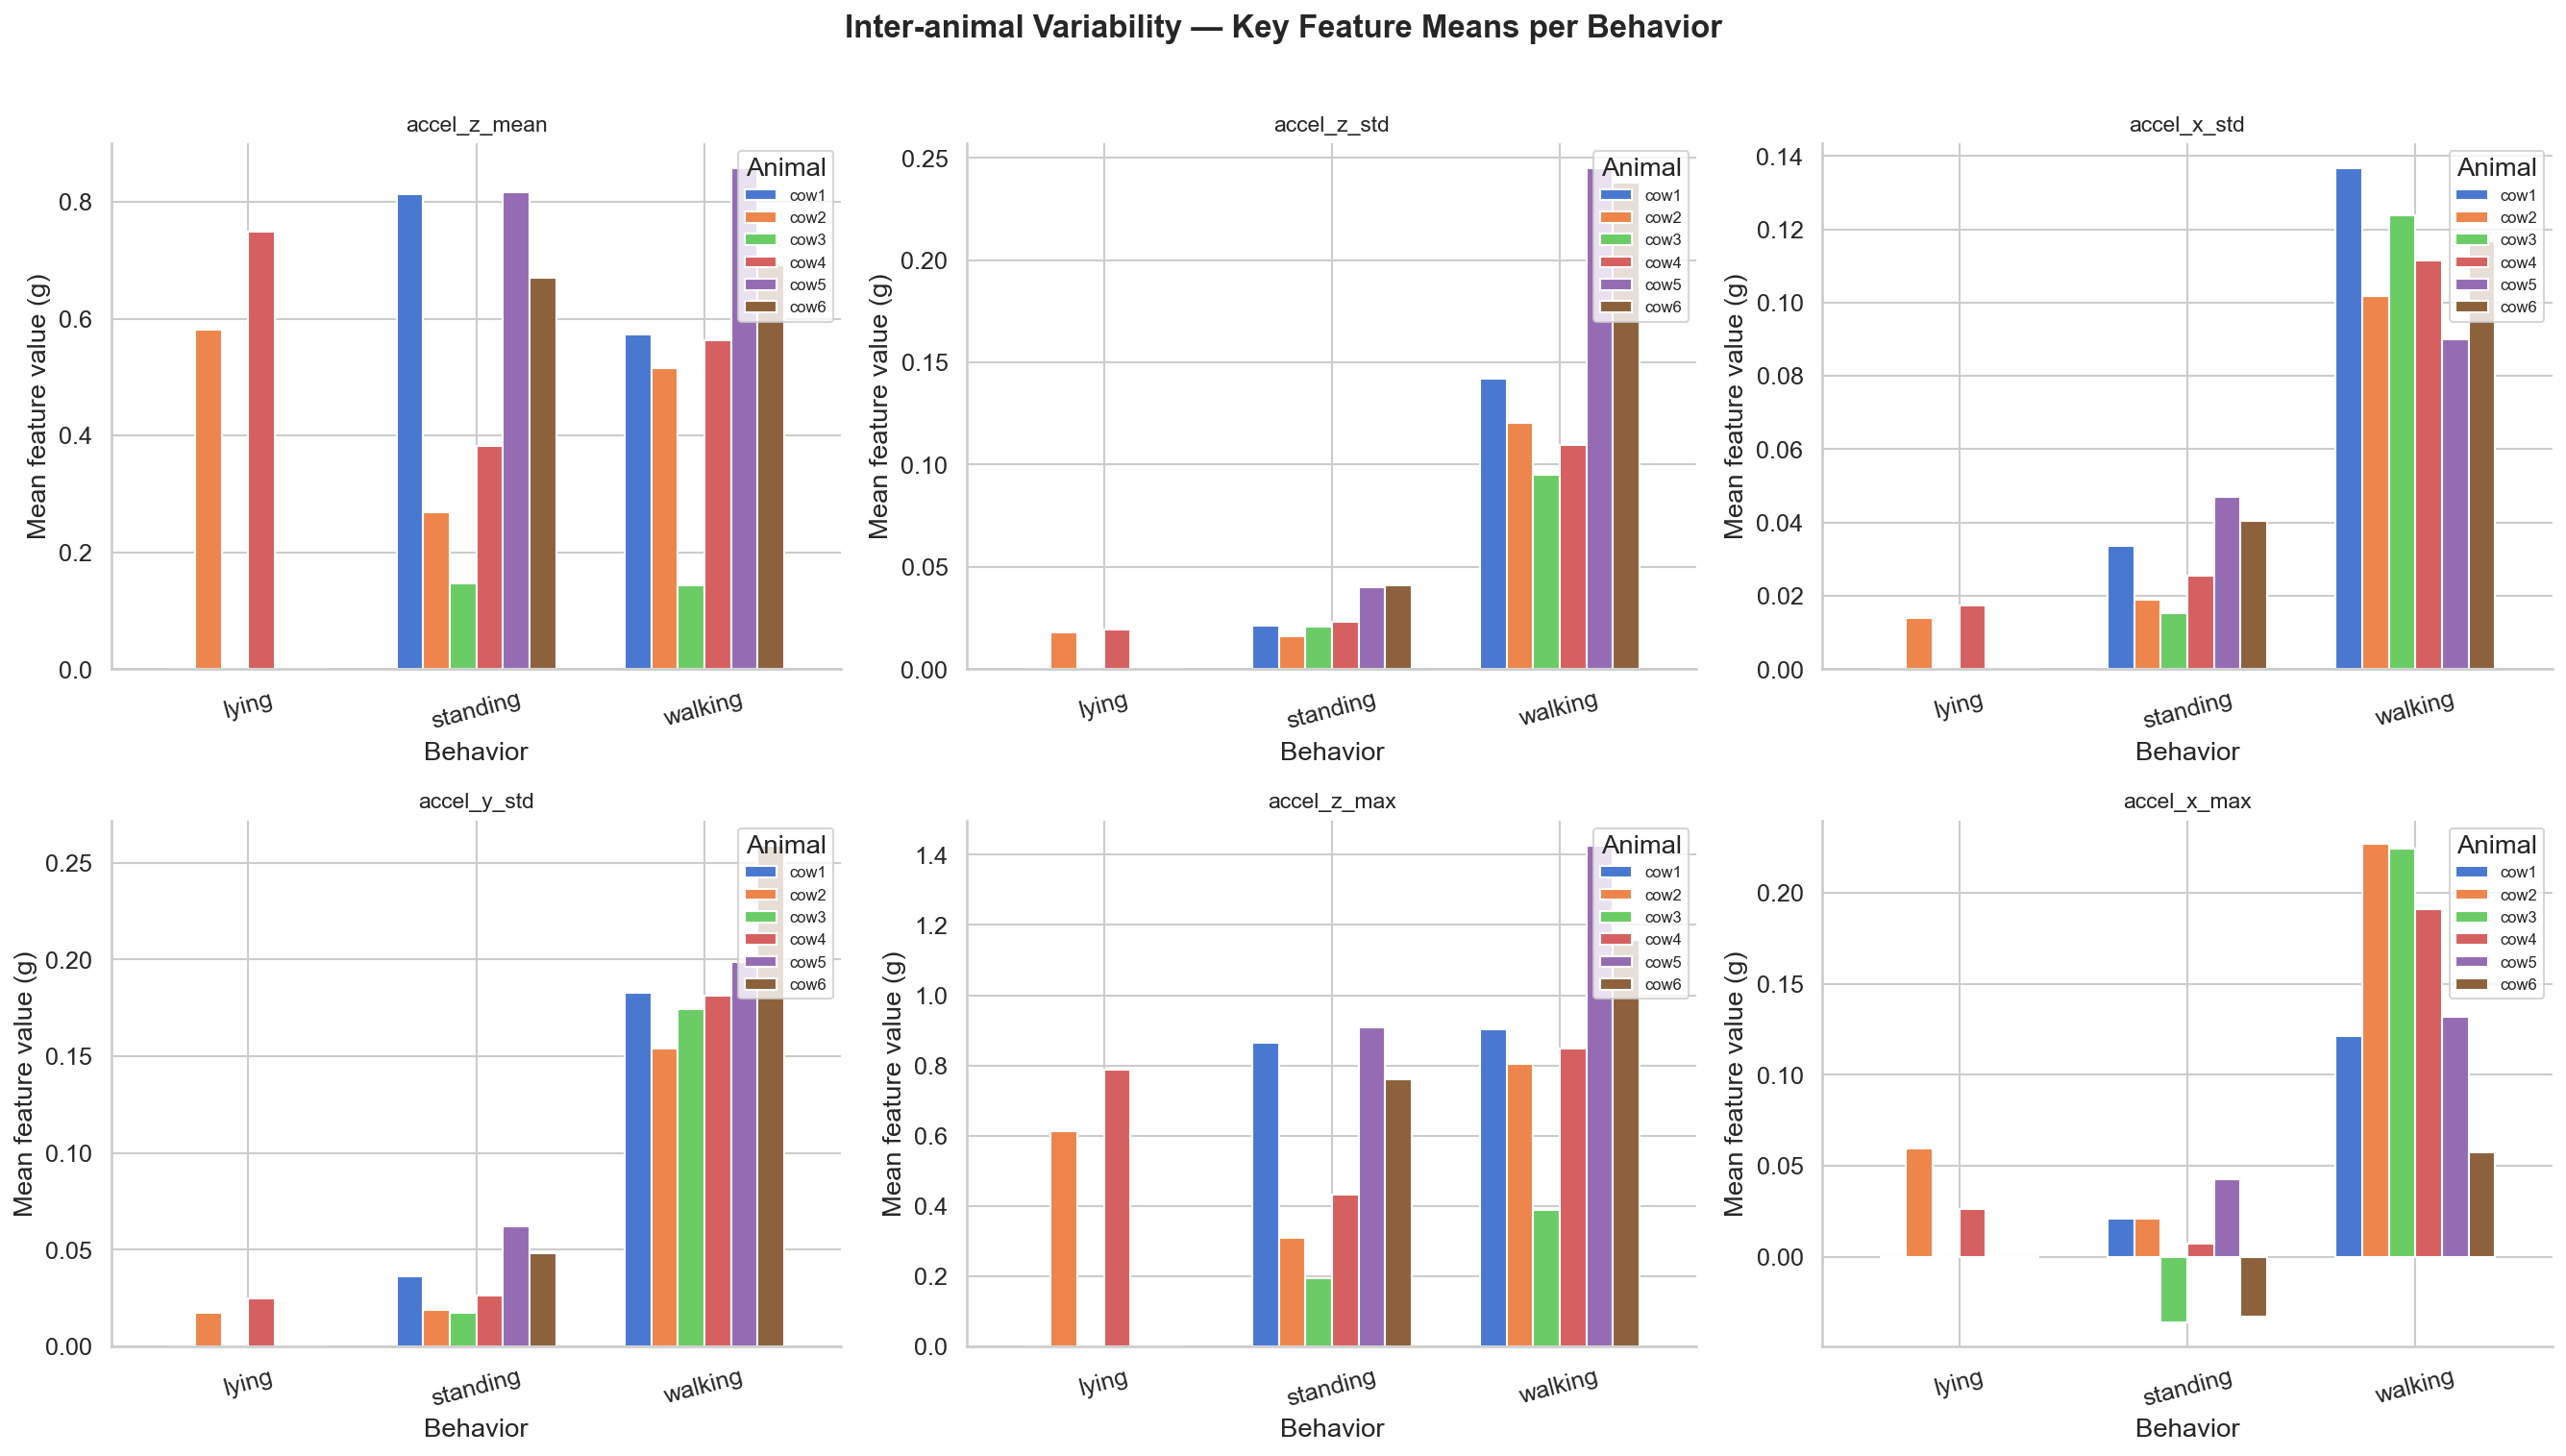

In [37]:
# Mean feature value per (animal, behavior) — deviation from class mean
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

key_features = ["accel_z_mean","accel_z_std","accel_x_std","accel_y_std","accel_z_max","accel_x_max"]

for ax, feat in zip(axes.flatten(), key_features):
    group_means = df_windows.groupby(["animal_id","label_simplified"])[feat].mean().unstack()
    group_means.T.plot(kind="bar", ax=ax, width=0.7)
    ax.set_title(feat, fontsize=11)
    ax.set_xlabel("Behavior")
    ax.set_ylabel("Mean feature value (g)")
    ax.legend(title="Animal", fontsize=8, loc="upper right")
    ax.tick_params(axis="x", rotation=15)

plt.suptitle("Inter-animal Variability — Key Feature Means per Behavior",
             fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


In [38]:
# Coefficient of variation: std_across_animals / mean_across_animals
cv_table = (
    df_windows.groupby(["animal_id","label_simplified"])[FEATURE_COLUMNS]
    .mean()
    .groupby("label_simplified")
    .agg(["mean","std"])
)
# Compute CV per feature per class
cv_rows = []
for feat in FEATURE_COLUMNS:
    for beh in SIMPLIFIED_STATES:
        try:
            m = cv_table[(feat,"mean")][beh]
            s = cv_table[(feat,"std")][beh]
            cv = abs(s/m)*100 if m != 0 else np.nan
            cv_rows.append({"feature":feat,"behavior":beh,"CV_%":round(cv,1)})
        except:
            pass
cv_df = pd.DataFrame(cv_rows).pivot(index="feature",columns="behavior",values="CV_%")
print("Coefficient of Variation (%) across animals — per feature and behavior")
print("High CV = high inter-animal variability")
print(cv_df.round(1).to_string())


Coefficient of Variation (%) across animals — per feature and behavior
High CV = high inter-animal variability
behavior       lying  standing  walking
feature                                
accel_x_max     54.9     842.8     42.1
accel_x_mean  2133.3      50.3     75.8
accel_x_min     53.5      38.2     28.9
accel_x_std     15.7      41.2     14.5
accel_y_max     13.3      28.9     12.9
accel_y_mean    13.4      35.3     23.4
accel_y_min     15.9      44.0     59.2
accel_y_std     24.8      50.9     18.8
accel_z_max     17.6      52.8     38.1
accel_z_mean    17.8      56.1     42.6
accel_z_min     20.6      59.5     64.9
accel_z_std      4.1      39.8     41.8


### 📌 Interpretation
- **High CV** (> 30%) for a feature/behavior combination means animals differ substantially — the classifier must learn a robust boundary despite individual variation.  
- **Low CV** features will have consistent thresholds across animals and are particularly valuable for generalisation.  
- The LOAO validation result directly reflects the average inter-animal variability seen here.


## 12. Class Imbalance <a id='12'></a>

Cattle spend most of their time lying and standing. This natural imbalance would bias a naive classifier
toward the majority class — which is why we use `class_weight='balanced'` in the Random Forest.


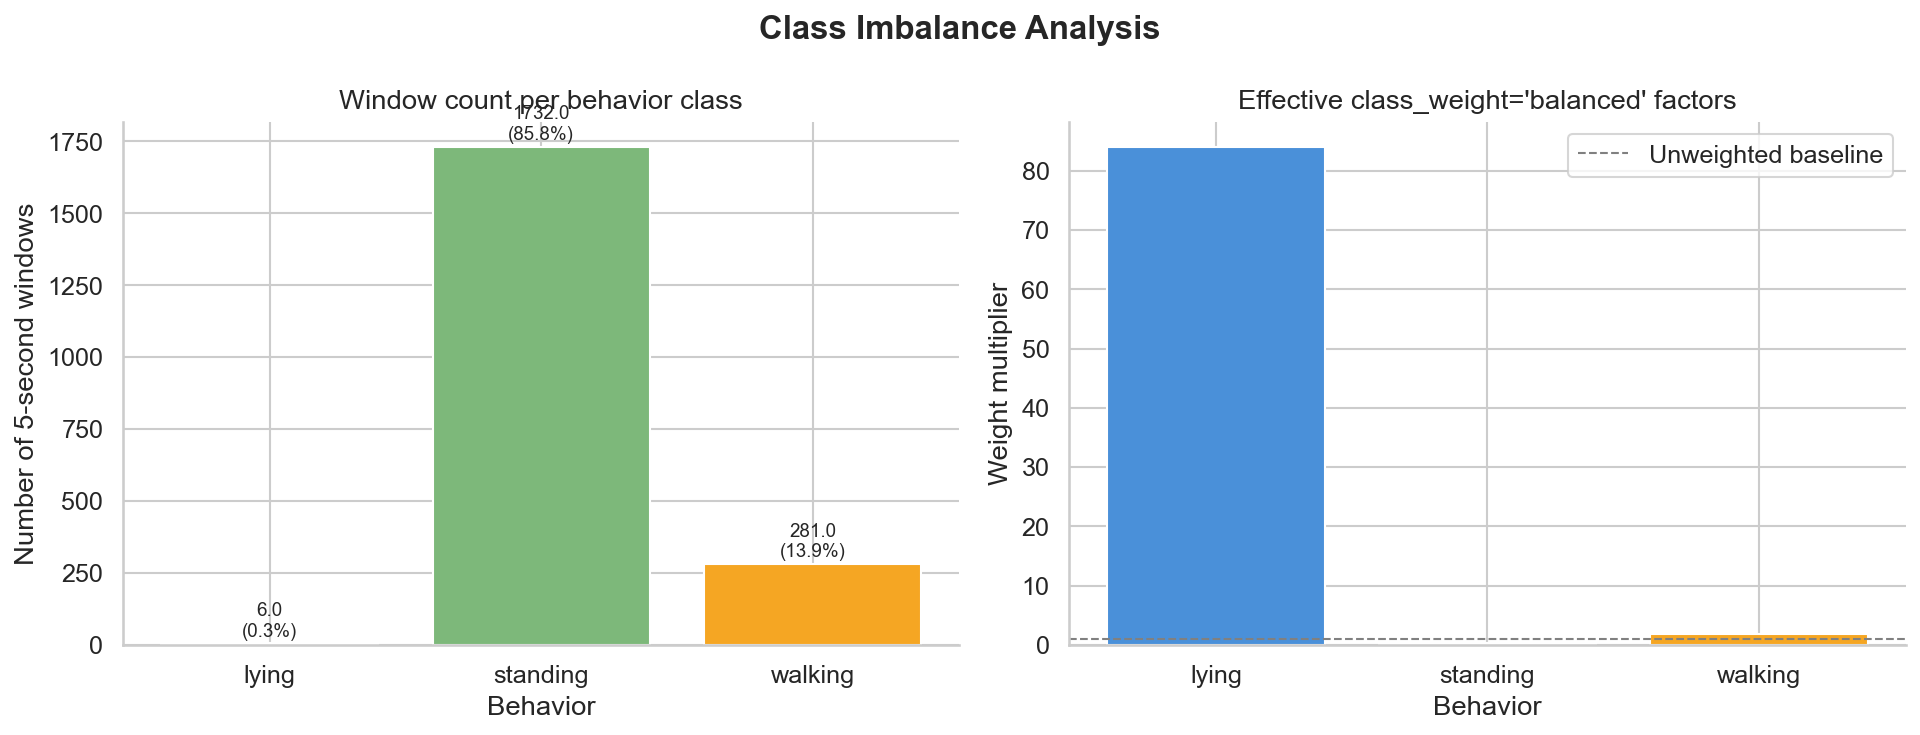


Imbalance ratio (majority / minority): 288.7x


In [39]:
class_counts = df_windows["label_simplified"].value_counts().reindex(SIMPLIFIED_STATES)
total = class_counts.sum()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Bar chart ────────────────────────────────────────────────────────────
bars = axes[0].bar(
    class_counts.index, class_counts.values,
    color=[BEHAVIOR_PALETTE[b] for b in class_counts.index], edgecolor="white"
)
for bar, val in zip(bars, class_counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+10,
                 f"{val}\n({val/total*100:.1f}%)", ha="center", va="bottom", fontsize=9)
axes[0].set_title("Window count per behavior class")
axes[0].set_ylabel("Number of 5-second windows")
axes[0].set_xlabel("Behavior")

# ── Effective class weights ───────────────────────────────────────────────
n_classes = len(SIMPLIFIED_STATES)
balanced_weights = {
    cls: total / (n_classes * cnt)
    for cls, cnt in class_counts.items()
}
axes[1].bar(
    list(balanced_weights.keys()),
    list(balanced_weights.values()),
    color=[BEHAVIOR_PALETTE[b] for b in balanced_weights.keys()], edgecolor="white"
)
axes[1].set_title("Effective class_weight='balanced' factors")
axes[1].set_ylabel("Weight multiplier")
axes[1].set_xlabel("Behavior")
axes[1].axhline(1.0, ls="--", color="gray", lw=1, label="Unweighted baseline")
axes[1].legend()

plt.suptitle("Class Imbalance Analysis", fontweight="bold")
plt.tight_layout()
plt.show()

print("\nImbalance ratio (majority / minority):",
      f"{class_counts.max()/class_counts.min():.1f}x")


### 📌 Interpretation
- **Imbalance is expected** in ethological datasets: cattle naturally spend ~50–60% of the day lying, ~30% standing, ~10% walking, and < 5% running.  
- Without correction, the classifier would maximise accuracy by always predicting "lying" or "standing."  
- `class_weight='balanced'` upweights minority classes (running, walking) proportionally, forcing the model to learn their patterns.  
- **Balanced accuracy** (used in LOAO evaluation) is the appropriate metric: it averages recall per class, treating each class equally regardless of its size.


In [40]:

# Create a copy of the dataframe to avoid modifying the raw data
df_clean = raw.copy()
# Map raw labels to simplified states using the BEHAVIOR_MAP defined earlier
df_clean['macro_behavior'] = df_clean['Label'].map(BEHAVIOR_MAP)
# Drop rows where macro_behavior is NaN (this effectively removes 'BLN', 'ETC', and empty strings)
df_clean = df_clean.dropna(subset=['macro_behavior'])
# Verify the new distribution of our 4 target classes
macro_counts = df_clean['macro_behavior'].value_counts().reset_index()
macro_counts.columns = ['macro_behavior', 'count']
macro_counts['percentage'] = (macro_counts['count'] / len(df_clean) * 100).round(2)
print(f"Total usable rows mapped to macro-behaviors: {len(df_clean):,}")
print(macro_counts.to_string(index=False))

Total usable rows mapped to macro-behaviors: 295,674
macro_behavior  count  percentage
      standing 244217       82.60
       walking  50199       16.98
         lying    764        0.26
       running    494        0.17


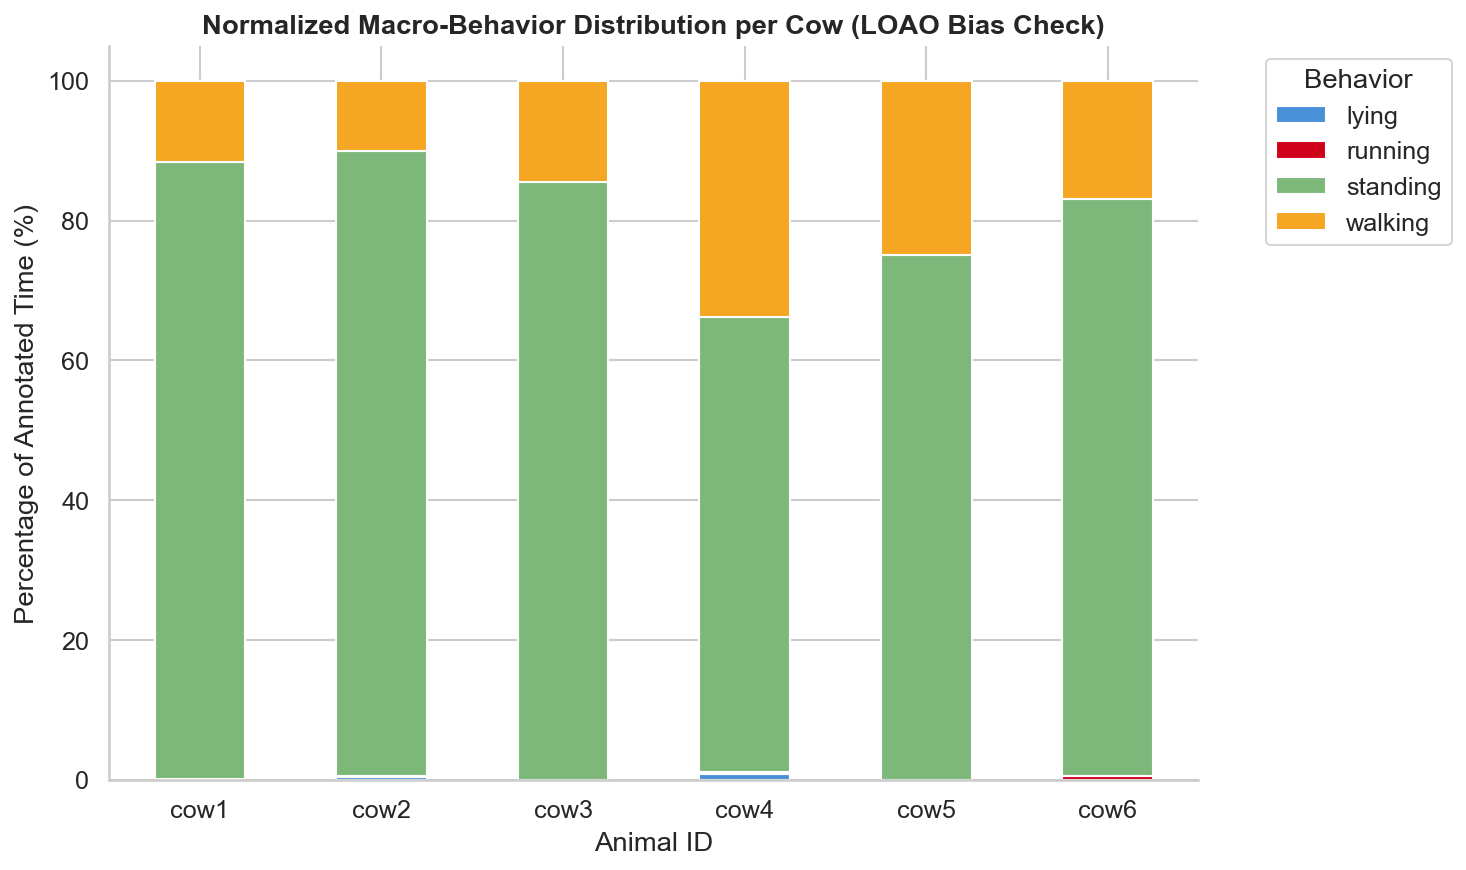

Absolute sample counts per animal per behavior:
macro_behavior  lying  running  standing  walking
animal_id                                        
cow1                0       57     48277     6376
cow2              360       50     75242     8437
cow3                0        0     44643     7532
cow4              404      190     33262    17248
cow5                0        0     14592     4846
cow6                0      197     28201     5760


In [41]:
# Calculate the percentage of each behavior per cow
animal_behavior_counts = df_clean.groupby(['animal_id', 'macro_behavior']).size().unstack(fill_value=0)
animal_behavior_pct = animal_behavior_counts.div(animal_behavior_counts.sum(axis=1), axis=0) * 100

# Map colors using your defined palette
plot_colors = [BEHAVIOR_PALETTE[col] for col in animal_behavior_pct.columns]

# Plotting the normalized stacked bar chart
fig, ax = plt.subplots(figsize=(10, 6))
animal_behavior_pct.plot(
    kind='bar', 
    stacked=True, 
    color=plot_colors,
    ax=ax,
    edgecolor='white'
)

plt.title("Normalized Macro-Behavior Distribution per Cow (LOAO Bias Check)", fontweight='bold')
plt.xlabel("Animal ID")
plt.ylabel("Percentage of Annotated Time (%)")
plt.legend(title="Behavior", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Print the absolute counts to highlight the density imbalance
print("Absolute sample counts per animal per behavior:")
print(animal_behavior_counts)
